In [1]:
# imports

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import folium
import osmnx as ox

import warnings
warnings.filterwarnings('ignore')


%matplotlib inline
pd.options.mode.chained_assignment = None  # default='warn'

/home/mijka/.pyenv/versions/3.8.12/envs/lewagon_current/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
pd.set_option('display.max_rows', 750)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', None)

In [3]:
### but :
### tenter de prédire les émissions de CO2 et la consommation totale d’énergie de bâtiments 
### non destinés à l’habitation pour lesquels elles n’ont pas encore été mesurées.

In [4]:
## source : contains KPI description
## https://data.seattle.gov/dataset/2016-Building-Energy-Benchmarking/2bpz-gwpy

# Extract & Load

In [5]:
ls -lh ./data

total 1,2M
-rw-r--r-- 1 mijka mijka 1,2M  5 févr. 09:37 2016_Building_Energy_Benchmarking.csv


In [6]:
path = './data/'
csv_path = path + '2016_Building_Energy_Benchmarking.csv'
df = pd.read_csv(csv_path, on_bad_lines='skip', low_memory=False)

# Explore


## Functions

In [7]:
def get_df_columns_na(df):
    counts = df.isna().sum()
    percentages = round(df.isna().mean() * 100, 1)
    null_values = pd.concat([counts, percentages], axis = 1, keys = ["count", "null_percent"])
    null_values['columns'] = null_values.index
    null_values = null_values[['columns', 'count', 'null_percent']]
    return null_values

In [8]:
def plot_df_xy(df, x_val, y_val, height_val = 20, width_val = 13):
    sns.catplot(data=df, x= x_val, y= y_val, kind="bar", height=height_val, aspect=width_val/height_val)
    sns.set(rc={'figure.figsize':(width_val,height_val)})
    plt.xticks(rotation=70)
    plt.tight_layout()

In [9]:
def show_nulls(df):
    top_sm_df_sort = get_df_columns_na(df).sort_values(by='null_percent',ascending=False)
    print(top_sm_df_sort)
    return plot_df_xy(top_sm_df_sort.reset_index(), 'null_percent', 'columns', 8)

## Cardinality

In [10]:
df.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [11]:
df.shape

(3376, 46)

In [12]:
df.dtypes

OSEBuildingID                        int64
DataYear                             int64
BuildingType                        object
PrimaryPropertyType                 object
PropertyName                        object
Address                             object
City                                object
State                               object
ZipCode                            float64
TaxParcelIdentificationNumber       object
CouncilDistrictCode                  int64
Neighborhood                        object
Latitude                           float64
Longitude                          float64
YearBuilt                            int64
NumberofBuildings                  float64
NumberofFloors                       int64
PropertyGFATotal                     int64
PropertyGFAParking                   int64
PropertyGFABuilding(s)               int64
ListOfAllPropertyUseTypes           object
LargestPropertyUseType              object
LargestPropertyUseTypeGFA          float64
SecondLarge

In [13]:
df.describe()

,OSEBuildingID,DataYear,ZipCode,CouncilDistrictCode,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),Comments,TotalGHGEmissions,GHGEmissionsIntensity
count,3376.000000,3376.0,3360.000000,3376.000000,3376.000000,3376.000000,3376.000000,3368.000000,3376.000000,3.376000e+03,3376.000000,3.376000e+03,3.356000e+03,1679.000000,596.000000,2533.000000,3369.000000,3370.000000,3367.000000,3367.000000,3.371000e+03,3.370000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,0.0,3367.000000,3367.000000
mean,21208.991114,2016.0,98116.949107,4.439277,47.624033,-122.334795,1968.573164,1.106888,4.709123,9.483354e+04,8001.526066,8.683201e+04,7.917764e+04,28444.075817,11738.675166,67.918674,54.732116,57.033798,134.232848,137.783932,5.403667e+06,5.276726e+06,2.745959e+05,1.086639e+06,3.707612e+06,1.368505e+04,1.368505e+06,NaN,119.723971,1.175916
std,12223.757015,0.0,18.615205,2.120625,0.047758,0.027203,33.088156,2.108402,5.494465,2.188376e+05,32326.723928,2.079398e+05,2.017034e+05,54392.917928,29331.199286,26.873271,56.273124,57.163330,139.287554,139.109807,2.161063e+07,1.593879e+07,3.912173e+06,4.352478e+06,1.485066e+07,6.709781e+04,6.709781e+06,NaN,538.832227,1.821452
min,1.000000,2016.0,98006.000000,1.000000,47.499170,-122.414250,1900.000000,0.000000,0.000000,1.128500e+04,0.000000,3.636000e+03,5.656000e+03,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-2.100000,0.000000e+00,0.000000e+00,0.000000e+00,-3.382680e+04,-1.154170e+05,0.000000e+00,0.000000e+00,NaN,-0.800000,-0.020000
25%,19990.750000,2016.0,98105.000000,3.000000,47.599860,-122.350662,1948.000000,1.000000,2.000000,2.848700e+04,0.000000,2.775600e+04,2.509475e+04,5000.000000,2239.000000,53.000000,27.900000,29.400000,74.699997,78.400002,9.251286e+05,9.701822e+05,0.000000e+00,1.874229e+05,6.394870e+05,0.000000e+00,0.000000e+00,NaN,9.495000,0.210000
50%,23112.000000,2016.0,98115.000000,4.000000,47.618675,-122.332495,1975.000000,1.000000,4.000000,4.417500e+04,0.000000,4.321600e+04,3.989400e+04,10664.000000,5043.000000,75.000000,38.599998,40.900002,96.199997,101.099998,1.803753e+06,1.904452e+06,0.000000e+00,3.451299e+05,1.177583e+06,3.237538e+03,3.237540e+05,NaN,33.920000,0.610000
75%,25994.250000,2016.0,98122.000000,7.000000,47.657115,-122.319407,1997.000000,1.000000,5.000000,9.099200e+04,0.000000,8.427625e+04,7.620025e+04,26640.000000,10138.750000,90.000000,60.400002,64.275002,143.899994,148.349998,4.222455e+06,4.381429e+06,0.000000e+00,8.293178e+05,2.829632e+06,1.189033e+04,1.189034e+06,NaN,93.940000,1.370000
max,50226.000000,2016.0,98272.000000,7.000000,47.733870,-122.220966,2015.000000,111.000000,99.000000,9.320156e+06,512608.000000,9.320156e+06,9.320156e+06,686750.000000,459748.000000,100.000000,834.400024,834.400024,2620.000000,2620.000000,8.739237e+08,4.716139e+08,1.349435e+08,1.925775e+08,6.570744e+08,2.979090e+06,2.979090e+08,NaN,16870.980000,34.090000


                                                         columns  count  \
Comments                                                Comments   3376   
Outlier                                                  Outlier   3344   
YearsENERGYSTARCertified                YearsENERGYSTARCertified   3257   
ThirdLargestPropertyUseType          ThirdLargestPropertyUseType   2780   
ThirdLargestPropertyUseTypeGFA    ThirdLargestPropertyUseTypeGFA   2780   
SecondLargestPropertyUseType        SecondLargestPropertyUseType   1697   
SecondLargestPropertyUseTypeGFA  SecondLargestPropertyUseTypeGFA   1697   
ENERGYSTARScore                                  ENERGYSTARScore    843   
LargestPropertyUseTypeGFA              LargestPropertyUseTypeGFA     20   
LargestPropertyUseType                    LargestPropertyUseType     20   
ZipCode                                                  ZipCode     16   
ListOfAllPropertyUseTypes              ListOfAllPropertyUseTypes      9   
SourceEUIWN(kBtu/sf)     

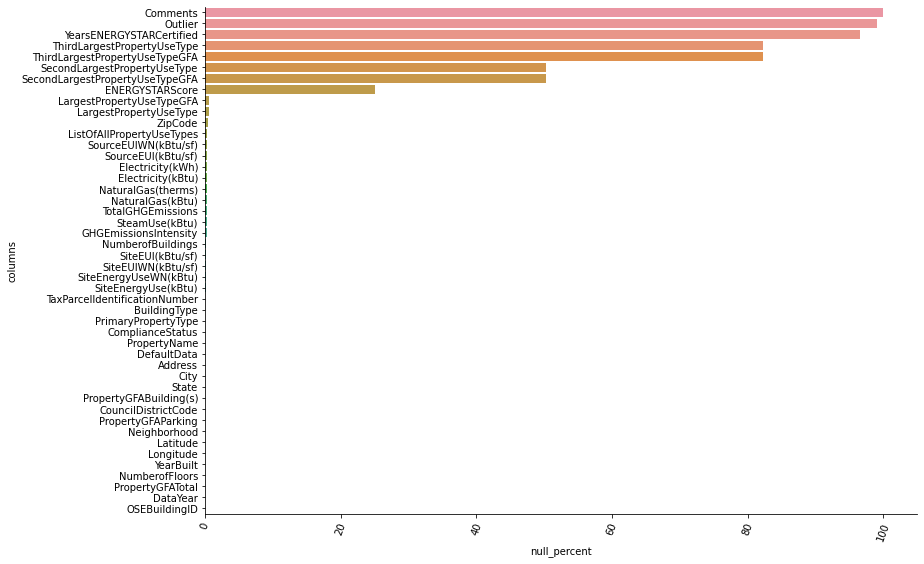

In [14]:
show_nulls(df)

## Duplicates

In [15]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
3371    False
3372    False
3373    False
3374    False
3375    False
Length: 3376, dtype: bool

In [16]:
len(df)-len(df.drop_duplicates())

0

In [17]:
df.groupby(df.columns.tolist(),as_index=False).size()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity,size


In [18]:
##df.groupby(['Longitude', 'Latitude'])['Crime type'].value_counts().to_frame('count')

## categories

In [19]:
df.select_dtypes(['category','object']).nunique()

BuildingType                        8
PrimaryPropertyType                24
PropertyName                     3362
Address                          3354
City                                1
State                               1
TaxParcelIdentificationNumber    3268
Neighborhood                       19
ListOfAllPropertyUseTypes         466
LargestPropertyUseType             56
SecondLargestPropertyUseType       50
ThirdLargestPropertyUseType        44
YearsENERGYSTARCertified           65
ComplianceStatus                    4
Outlier                             2
dtype: int64

In [20]:
df['ZipCode'].unique()

array([98101., 98121., 98104., 98154., 98118., 98105., 98112., 98125.,
       98109., 98070., 98108., 98199., 98115., 98107., 98144., 98103.,
       98119., 98136., 98122., 98126., 98133., 98146., 98033., 98106.,
       98111., 98134., 98117., 98116., 98191., 98164., 98195., 98185.,
       98181., 98102., 98168., 98155., 98006., 98124., 98053., 98012.,
       98013., 98028., 98178., 98114., 98127., 98165., 98011., 98198.,
       98113., 98040., 98204., 98177., 98020., 98272., 98145.,    nan])

In [21]:
df['Comments'].unique()

array([nan])

In [22]:
df['Comments'].nunique()

0

In [23]:
for column in df.columns:
    if df[column].nunique()<20:
        print('Colonne {}, valeurs uniques :\n{}\n'.format(column, df[column].unique()))
    else:
        print('Colonne {}, {} valeurs uniques'.format(column, df[column].nunique()))

Colonne OSEBuildingID, 3376 valeurs uniques
Colonne DataYear, valeurs uniques :
[2016]

Colonne BuildingType, valeurs uniques :
['NonResidential' 'Nonresidential COS' 'Multifamily MR (5-9)'
 'SPS-District K-12' 'Campus' 'Multifamily LR (1-4)'
 'Multifamily HR (10+)' 'Nonresidential WA']

Colonne PrimaryPropertyType, 24 valeurs uniques
Colonne PropertyName, 3362 valeurs uniques
Colonne Address, 3354 valeurs uniques
Colonne City, valeurs uniques :
['Seattle']

Colonne State, valeurs uniques :
['WA']

Colonne ZipCode, 55 valeurs uniques
Colonne TaxParcelIdentificationNumber, 3268 valeurs uniques
Colonne CouncilDistrictCode, valeurs uniques :
[7 3 2 4 5 6 1]

Colonne Neighborhood, valeurs uniques :
['DOWNTOWN' 'SOUTHEAST' 'NORTHEAST' 'EAST' 'Central' 'NORTH'
 'MAGNOLIA / QUEEN ANNE' 'LAKE UNION' 'GREATER DUWAMISH' 'BALLARD'
 'NORTHWEST' 'CENTRAL' 'SOUTHWEST' 'DELRIDGE' 'Ballard' 'North' 'Delridge'
 'Northwest' 'DELRIDGE NEIGHBORHOODS']

Colonne Latitude, 2876 valeurs uniques
Colonne Longit

# Cleaning

## Distribution pre-cleaning

### Fonctions

In [24]:
def UVA_numeric2(data, i):
  '''
  Univariate_Analysis_numeric
  takes a group of variables (INTEGER and FLOAT) and plot/print all the descriptives and properties along with KDE.

  Runs a loop: calculate all the descriptives of i(th) variable and plot/print it
  '''
  # calculating descriptives of variable
  mini = data[i].min()
  maxi = data[i].max()
  ran = data[i].max()-data[i].min()
  mean = data[i].mean()
  median = data[i].median()
  st_dev = data[i].std()
  skew = data[i].skew()
  kurt = data[i].kurtosis()

  # calculating points of standard deviation
  points = mean-st_dev, mean+st_dev

  #Plotting the variable with every information
  sns.kdeplot(data[i], shade=True)
  sns.lineplot(points, [0,0], color = 'black', label = "std_dev")
  sns.scatterplot([mini,maxi], [0,0], color = 'orange', label = "min/max")
  sns.scatterplot([mean], [0], color = 'red', label = "mean")
  sns.scatterplot([median], [0], color = 'blue', label = "median")
  plt.xlabel('{}'.format(i), fontsize = 20)
  plt.ylabel('density')
  plt.title('std_dev = {}; kurtosis = {};\nskew = {}; range = {}\nmean = {}; median = {}'.format((round(points[0],2),round(points[1],2)),
                                                                                                   round(kurt,2),
                                                                                                   round(skew,2),
                                                                                                   (round(mini,2),round(maxi,2),round(ran,2)),
                                                                                                   round(mean,2),
                                                                                                   round(median,2)))

In [25]:
# afficher détail Boxplot / UVA_num pour chaque indicateur par ligne

def UVA_num_plus(df, indicators_list):
  
    for i in indicators_list:
        plt.figure(figsize = (15, 20))
        df_indic = df[i]

        plt.subplot(5,2,1)
        sns.boxplot(y=df_indic)
        plt.xlabel(f'{i}', fontsize = 20)


        plt.subplot(5,2,2)
        UVA_numeric2(df, i)


### Infos

In [26]:
num_cols = df.columns[df.dtypes == 'float64']
num_cols

Index(['ZipCode', 'Latitude', 'Longitude', 'NumberofBuildings',
       'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseTypeGFA', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)',
       'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
       'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)',
       'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)',
       'NaturalGas(kBtu)', 'Comments', 'TotalGHGEmissions',
       'GHGEmissionsIntensity'],
      dtype='object')

TypeError: lineplot() takes from 0 to 1 positional arguments but 2 were given

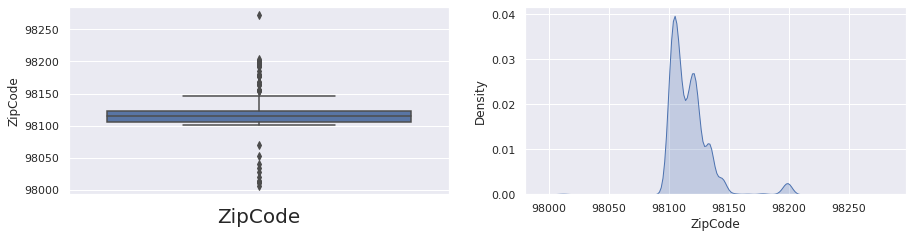

In [27]:
UVA_num_plus(df, num_cols)

In [29]:
num_cols

Index(['ZipCode', 'Latitude', 'Longitude', 'NumberofBuildings',
       'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseTypeGFA', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)',
       'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
       'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)',
       'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)',
       'NaturalGas(kBtu)', 'Comments', 'TotalGHGEmissions',
       'GHGEmissionsIntensity'],
      dtype='object')

In [30]:
df['NumberofBuildings'].value_counts()

1.0      3175
0.0        92
2.0        37
3.0        22
4.0        12
5.0        10
6.0         5
8.0         3
10.0        2
14.0        2
9.0         2
7.0         1
11.0        1
16.0        1
23.0        1
27.0        1
111.0       1
Name: NumberofBuildings, dtype: int64

In [31]:
# si volonté de réduire skewness => faire log
# bonus : faire log pour comparer (s'approche de la distribution normale)
# skewness négative => check doc

## Feature reduction

In [32]:
df.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


### Retrait colonne 'Outlier'


In [33]:
df.shape

(3376, 46)

In [34]:
df['Outlier'].head()

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
Name: Outlier, dtype: object

In [35]:
df = df[df['Outlier'].isnull()]

In [36]:
df.shape

(3344, 46)

In [37]:
df['Outlier'].value_counts()

Series([], Name: Outlier, dtype: int64)

### Retrait des colonnes non-utilisables / redondantes

In [230]:
df.columns

Index(['DataYear', 'BuildingType', 'PrimaryPropertyType',
       'CouncilDistrictCode', 'Neighborhood', 'Latitude', 'Longitude',
       'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFAParking', 'PropertyGFABuilding(s)',
       'LargestPropertyUseType', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA',
       'SiteEnergyUseWN(kBtu)', 'DefaultData', 'ComplianceStatus',
       'TotalGHGEmissions', 'geometry'],
      dtype='object')

In [235]:
df['geometry'].nunique()

1473

In [38]:
cols_to_drop = [
    'DataYear', #annee collecte donnees
    'OSEBuildingID', # inutilisé
    'City', #une seule valeur unique
    'State', #une seule valeur unique
    'PropertyName', #inutilisé
    'TaxParcelIdentificationNumber', #inutilisé
    'Address', #redondant avec latitude / longitude
    #'ZipCode', #redondant avec latitude / longitude
    'CouncilDistrictCode', #redondant zipcode
    'Latitude', #redondant zipcode
    'Longitude', #redondant zipcode
    #'Neighborhood',
    'Comments', # 100% de données manquantes
    'Outlier', # 99% de données manquantes, a permis de retirer précedemment les lignes libellées "outlier"
    'YearsENERGYSTARCertified', #96.5% de données manquantes
    #'ENERGYSTARScore', # 25% de données manquantes, à garder pour évaluer si il permet d'améliorer pred ou pas des modèles
    'ListOfAllPropertyUseTypes' # redondant
]

In [39]:
df.shape

(3344, 46)

In [ ]:
cols_to_drop += [
    'LargestPropertyUseTypeGFA',
    'SecondLargestPropertyUseTypeGFA',
    'ThirdLargestPropertyUseTypeGFA,
    'ComplianceStatus',
    'DefaultData',
    'geometry'
]

In [40]:
cols_to_drop += [
    'SiteEUI(kBtu/sf)',
    'SiteEUIWN(kBtu/sf)',
    'SourceEUI(kBtu/sf)',
    'SourceEUIWN(kBtu/sf)',
    'SiteEnergyUse(kBtu)',
    #'SiteEnergyUseWN(kBtu)', -- comporte une prédiction
    'SteamUse(kBtu)',
    'Electricity(kWh)',
    'Electricity(kBtu)',
    'NaturalGas(therms)',
    'NaturalGas(kBtu)',
    'GHGEmissionsIntensity'
]

In [41]:
df['SiteEnergyUseWN(kBtu)'].nunique()

3309

In [42]:
df['SiteEnergyUseWN(kBtu)'].value_counts()

0.000          29
2127889.250     2
630412.625      1
1355995.250     1
1439042.250     1
               ..
1325461.750     1
3859690.500     1
1214408.750     1
6853384.500     1
1293722.375     1
Name: SiteEnergyUseWN(kBtu), Length: 3309, dtype: int64

In [43]:
cols_to_drop

['OSEBuildingID',
 'City',
 'State',
 'PropertyName',
 'TaxParcelIdentificationNumber',
 'Address',
 'ZipCode',
 'Comments',
 'Outlier',
 'YearsENERGYSTARCertified',
 'ENERGYSTARScore',
 'ListOfAllPropertyUseTypes',
 'SiteEUI(kBtu/sf)',
 'SiteEUIWN(kBtu/sf)',
 'SourceEUI(kBtu/sf)',
 'SourceEUIWN(kBtu/sf)',
 'SiteEnergyUse(kBtu)',
 'SteamUse(kBtu)',
 'Electricity(kWh)',
 'Electricity(kBtu)',
 'NaturalGas(therms)',
 'NaturalGas(kBtu)',
 'GHGEmissionsIntensity']

In [44]:
df.shape

(3344, 46)

In [45]:
df.drop(cols_to_drop, axis=1, inplace=True)

In [46]:
df.shape

(3344, 23)

                                                         columns  count  \
ThirdLargestPropertyUseTypeGFA    ThirdLargestPropertyUseTypeGFA   2755   
ThirdLargestPropertyUseType          ThirdLargestPropertyUseType   2755   
SecondLargestPropertyUseTypeGFA  SecondLargestPropertyUseTypeGFA   1681   
SecondLargestPropertyUseType        SecondLargestPropertyUseType   1681   
LargestPropertyUseTypeGFA              LargestPropertyUseTypeGFA     20   
LargestPropertyUseType                    LargestPropertyUseType     20   
TotalGHGEmissions                              TotalGHGEmissions      9   
SiteEnergyUseWN(kBtu)                      SiteEnergyUseWN(kBtu)      6   
NumberofBuildings                              NumberofBuildings      8   
PropertyGFABuilding(s)                    PropertyGFABuilding(s)      0   
ComplianceStatus                                ComplianceStatus      0   
DefaultData                                          DefaultData      0   
DataYear                 

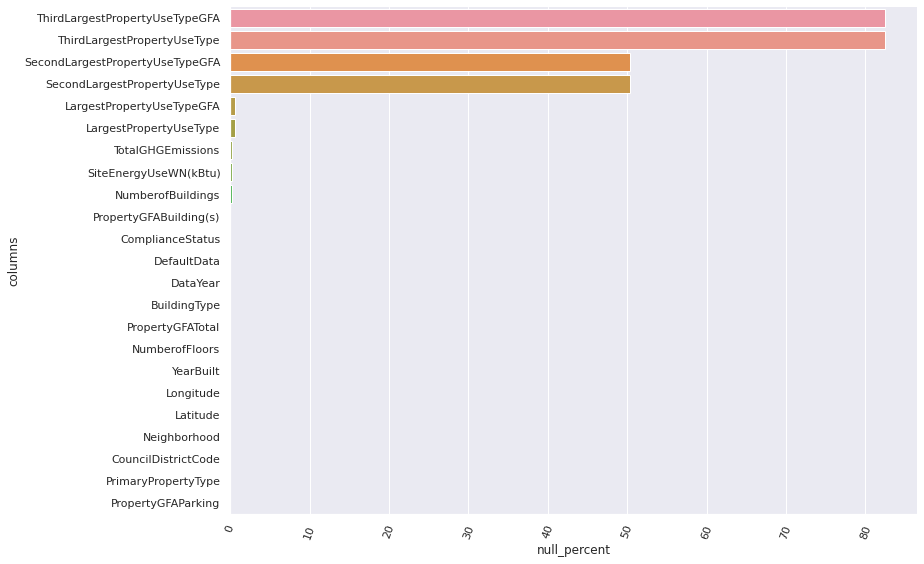

In [47]:
show_nulls(df)

In [48]:
### remplir vides

## données aberrantes / normalisation

### Valeurs catégorielles

#### General infos

In [49]:
cat_cols = df.columns[df.dtypes == 'object']
cat_cols

Index(['BuildingType', 'PrimaryPropertyType', 'Neighborhood',
       'LargestPropertyUseType', 'SecondLargestPropertyUseType',
       'ThirdLargestPropertyUseType', 'ComplianceStatus'],
      dtype='object')

In [50]:
df[cat_cols].describe()

,BuildingType,PrimaryPropertyType,Neighborhood,LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,ComplianceStatus
count,3344,3344,3344,3324,1663,589,3344
unique,8,24,19,56,50,44,4
top,NonResidential,Low-Rise Multifamily,DOWNTOWN,Multifamily Housing,Parking,Retail Store,Compliant
freq,1445,975,565,1651,968,109,3211


In [51]:
df[cat_cols]

,BuildingType,PrimaryPropertyType,Neighborhood,LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,ComplianceStatus
0,NonResidential,Hotel,DOWNTOWN,Hotel,NaN,NaN,Compliant
1,NonResidential,Hotel,DOWNTOWN,Hotel,Parking,Restaurant,Compliant
2,NonResidential,Hotel,DOWNTOWN,Hotel,NaN,NaN,Compliant
3,NonResidential,Hotel,DOWNTOWN,Hotel,NaN,NaN,Compliant
4,NonResidential,Hotel,DOWNTOWN,Hotel,Parking,Swimming Pool,Compliant
...,...,...,...,...,...,...,...
3371,Nonresidential COS,Office,GREATER DUWAMISH,Office,NaN,NaN,Error - Correct Default Data
3372,Nonresidential COS,Other,DOWNTOWN,Other - Recreation,NaN,NaN,Compliant
3373,Nonresidential COS,Other,MAGNOLIA / QUEEN ANNE,Other - Recreation,Fitness Center/Health Club/Gym,Swimming Pool,Compliant
3374,Nonresidential COS,Mixed Use Property,GREATER DUWAMISH,Other - Recreation,Fitness Center/Health Club/Gym,Pre-school/Daycare,Compliant


In [52]:
#df['ENERGYSTARScore'].value_counts()

In [53]:
def print_cats(df, cat_cols):
    for column in cat_cols:
        print('--------------------------------------------')
        print('--------------------------------------------')
        print(f'Column : {column}')
        print('----')
        #print(df[f'{column}'].value_counts())
        uni_list = df[f'{column}'].unique()
        #print(sorted(uni_list))
        print(uni_list)
        print('')
        print('')
    
    

In [54]:
print_cats(df, cat_cols)

--------------------------------------------
--------------------------------------------
Column : BuildingType
----
['NonResidential' 'Nonresidential COS' 'Multifamily MR (5-9)'
 'SPS-District K-12' 'Campus' 'Multifamily LR (1-4)'
 'Multifamily HR (10+)' 'Nonresidential WA']


--------------------------------------------
--------------------------------------------
Column : PrimaryPropertyType
----
['Hotel' 'Other' 'Mid-Rise Multifamily' 'Mixed Use Property' 'K-12 School'
 'University' 'Small- and Mid-Sized Office' 'Self-Storage Facility'
 'Warehouse' 'Large Office' 'Senior Care Community' 'Medical Office'
 'Retail Store' 'Hospital' 'Residence Hall' 'Distribution Center'
 'Worship Facility' 'Low-Rise Multifamily' 'Supermarket / Grocery Store'
 'Laboratory' 'Refrigerated Warehouse' 'Restaurant'
 'High-Rise Multifamily' 'Office']


--------------------------------------------
--------------------------------------------
Column : Neighborhood
----
['DOWNTOWN' 'SOUTHEAST' 'NORTHEAST' 'EAS

#### Neighborhood

In [55]:
#df['ENERGYSTARScore'].value_counts()

In [56]:
#from sklearn import preprocessing
#le = preprocessing.LabelEncoder()

In [57]:
#df[cat_cols] = le.fit_transform(df[cat_cols].astype(str))

In [58]:
#df['Neighborhood'].value_counts()
print(sorted(df['Neighborhood'].unique()))

['BALLARD', 'Ballard', 'CENTRAL', 'Central', 'DELRIDGE', 'DELRIDGE NEIGHBORHOODS', 'DOWNTOWN', 'Delridge', 'EAST', 'GREATER DUWAMISH', 'LAKE UNION', 'MAGNOLIA / QUEEN ANNE', 'NORTH', 'NORTHEAST', 'NORTHWEST', 'North', 'Northwest', 'SOUTHEAST', 'SOUTHWEST']


In [59]:
# TotalGHGEmissions

In [60]:
df['Neighborhood'] = df['Neighborhood'].str.upper()
df['Neighborhood'].loc[df['Neighborhood'] == 'DELRIDGE NEIGHBORHOODS'] = 'DELRIDGE'

In [61]:
df['Neighborhood'].value_counts()

DOWNTOWN                 565
EAST                     449
MAGNOLIA / QUEEN ANNE    419
GREATER DUWAMISH         371
NORTHEAST                277
LAKE UNION               251
NORTHWEST                221
NORTH                    186
SOUTHWEST                160
BALLARD                  133
CENTRAL                  132
SOUTHEAST                 95
DELRIDGE                  85
Name: Neighborhood, dtype: int64

In [62]:
#### PropertyTypes

In [63]:
#df['ENERGYSTARScore'].value_counts()

In [64]:
#from sklearn import preprocessing
#le = preprocessing.LabelEncoder()

In [65]:
#df[cat_cols] = le.fit_transform(df[cat_cols].astype(str))

In [66]:
#df[df.columns[df.isnull().any()]].isnull().sum()

In [67]:
#df[df.columns[df.isnull().any()]].isnull().sum() * 100 / df.shape[0]

In [68]:
df['ThirdLargestPropertyUseType'].unique()

array([nan, 'Restaurant', 'Swimming Pool', 'Data Center', 'Office',
       'Retail Store', 'Other - Entertainment/Public Assembly',
       'Non-Refrigerated Warehouse', 'Other', 'Distribution Center',
       'Food Service', 'Other - Services', 'Medical Office', 'Parking',
       'Other - Utility', 'Other - Lodging/Residential', 'K-12 School',
       'Fitness Center/Health Club/Gym', 'Social/Meeting Hall',
       'Pre-school/Daycare', 'Convenience Store without Gas Station',
       'Financial Office', 'Other - Restaurant/Bar', 'Other - Education',
       'Multifamily Housing', 'Laboratory', 'Bank Branch', 'Hotel',
       'Personal Services (Health/Beauty, Dry Cleaning, etc)',
       'Other - Recreation', 'Self-Storage Facility',
       'Other - Technology/Science', 'Refrigerated Warehouse',
       'Fast Food Restaurant', 'Bar/Nightclub',
       'Manufacturing/Industrial Plant', 'Food Sales',
       'Supermarket/Grocery Store', 'Other/Specialty Hospital',
       'Worship Facility', 'Stri

In [69]:
df['ThirdLargestPropertyUseType'].nunique()

44

In [70]:
# check error
#UVA_num_plus(df, ['DefaultData'])

In [71]:
df['SecondLargestPropertyUseType'].unique()

array([nan, 'Parking', 'Office', 'Restaurant', 'K-12 School',
       'Laboratory', 'Refrigerated Warehouse',
       'Non-Refrigerated Warehouse', 'Other - Education',
       'Vocational School', 'Retail Store',
       'Personal Services (Health/Beauty, Dry Cleaning, etc)',
       'Other - Entertainment/Public Assembly', 'Data Center',
       'Swimming Pool', 'Other', 'Courthouse', 'Residence Hall/Dormitory',
       'Distribution Center', 'Self-Storage Facility', 'Other - Services',
       'Movie Theater', 'Supermarket/Grocery Store', 'Medical Office',
       'Other - Recreation', 'Convenience Store without Gas Station',
       'Performing Arts', 'College/University', 'Other - Restaurant/Bar',
       'Adult Education', 'Enclosed Mall', 'Multifamily Housing',
       'Bar/Nightclub', 'Financial Office',
       'Repair Services (Vehicle, Shoe, Locksmith, etc)',
       'Manufacturing/Industrial Plant', 'Other - Lodging/Residential',
       'Bank Branch', 'Food Service', 'Worship Facility',


In [72]:
#df['LargestPropertyUseType'].value_counts()

In [73]:
df['LargestPropertyUseType'].isna().count()

3344

In [74]:
df['SecondLargestPropertyUseType'].nunique()

50

In [75]:
#df['ThirdLargestPropertyUseType'].value_counts()

In [76]:
df['ThirdLargestPropertyUseType'].isna().count()

3344

In [77]:
df.loc[df['LargestPropertyUseType'].isna()]

,DataYear,BuildingType,PrimaryPropertyType,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,SiteEnergyUseWN(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions
353,2016,NonResidential,Self-Storage Facility,6,BALLARD,47.66838,-122.39310,1946,2.0,2,111445,0,111445,NaN,NaN,NaN,NaN,NaN,NaN,6.076957e+06,False,Compliant,163.83
578,2016,NonResidential,Small- and Mid-Sized Office,7,DOWNTOWN,47.60380,-122.33293,1924,NaN,4,63150,0,63150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Non-Compliant,NaN
758,2016,Multifamily LR (1-4),Low-Rise Multifamily,4,NORTHEAST,47.68149,-122.26471,1977,NaN,3,33166,0,33166,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Non-Compliant,NaN
1077,2016,Multifamily HR (10+),High-Rise Multifamily,7,DOWNTOWN,47.61733,-122.35376,1999,1.0,13,219874,0,219874,NaN,NaN,NaN,NaN,NaN,NaN,1.399351e+07,False,Compliant,408.82
1147,2016,NonResidential,Hotel,7,DOWNTOWN,47.61203,-122.34165,1910,1.0,8,61721,0,61721,NaN,NaN,NaN,NaN,NaN,NaN,2.968430e+06,False,Compliant,36.92
1483,2016,Multifamily MR (5-9),Mid-Rise Multifamily,7,MAGNOLIA / QUEEN ANNE,47.62390,-122.36437,2000,1.0,5,45715,0,45715,NaN,NaN,NaN,NaN,NaN,NaN,1.329285e+06,False,Compliant,8.99
1756,2016,Multifamily HR (10+),High-Rise Multifamily,3,EAST,47.61056,-122.32525,1982,1.0,17,76855,0,76855,NaN,NaN,NaN,NaN,NaN,NaN,2.959676e+06,False,Compliant,18.95
1768,2016,Multifamily LR (1-4),Low-Rise Multifamily,1,SOUTHWEST,47.54731,-122.38656,1992,NaN,4,29357,0,29357,NaN,NaN,NaN,NaN,NaN,NaN,5.937986e+05,False,Compliant,NaN
1792,2016,Multifamily LR (1-4),Low-Rise Multifamily,7,MAGNOLIA / QUEEN ANNE,47.62479,-122.36364,1957,NaN,4,23636,0,23636,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Non-Compliant,NaN
2321,2016,Multifamily LR (1-4),Low-Rise Multifamily,4,NORTHEAST,47.67025,-122.31232,1963,NaN,4,28472,0,28472,NaN,NaN,NaN,NaN,NaN,NaN,7.975070e+05,False,Compliant,NaN


In [78]:
#df['ENERGYSTARScore'].value_counts()

In [79]:
### check valeurs erronnées / outliers (negatives ?)

#### garder uniquement batiments non-résidentiels

##### Col BuildingType

In [80]:
# garder uniquement batiments non-résidentiels
df['BuildingType'].unique()

array(['NonResidential', 'Nonresidential COS', 'Multifamily MR (5-9)',
       'SPS-District K-12', 'Campus', 'Multifamily LR (1-4)',
       'Multifamily HR (10+)', 'Nonresidential WA'], dtype=object)

In [81]:
# get rows with BuildingType with 'Multifamily' prefix
# count code values with 200 prefix
df['BuildingType'].loc[df['BuildingType'].str.startswith('Multifamily')]

9       Multifamily MR (5-9)
165     Multifamily MR (5-9)
173     Multifamily MR (5-9)
188     Multifamily LR (1-4)
189     Multifamily MR (5-9)
                ...         
3353    Multifamily MR (5-9)
3354    Multifamily MR (5-9)
3355    Multifamily MR (5-9)
3357    Multifamily MR (5-9)
3358    Multifamily LR (1-4)
Name: BuildingType, Length: 1693, dtype: object

In [82]:
df.shape

(3344, 23)

In [83]:
# remove "MultiFamily" related rows
df = df.loc[~df['BuildingType'].str.startswith('Multifamily')]

In [84]:
df['BuildingType'].unique()

array(['NonResidential', 'Nonresidential COS', 'SPS-District K-12',
       'Campus', 'Nonresidential WA'], dtype=object)

In [85]:
#df['BuildingType'].unique()

In [86]:
df.shape

(1651, 23)

In [87]:
df['BuildingType'].unique()

array(['NonResidential', 'Nonresidential COS', 'SPS-District K-12',
       'Campus', 'Nonresidential WA'], dtype=object)

In [88]:
df['BuildingType'].value_counts()

NonResidential        1445
SPS-District K-12       97
Nonresidential COS      84
Campus                  24
Nonresidential WA        1
Name: BuildingType, dtype: int64

In [89]:
#from sklearn import preprocessing
#le = preprocessing.LabelEncoder()

In [90]:
#df[cat_cols] = le.fit_transform(df[cat_cols].astype(str))

##### PrimaryPropertyType

In [91]:
df['PrimaryPropertyType'].isna().sum()

0

In [92]:
df['PrimaryPropertyType'].value_counts()

Small- and Mid-Sized Office    289
Other                          247
Warehouse                      187
Large Office                   170
K-12 School                    137
Mixed Use Property             114
Retail Store                    89
Hotel                           75
Worship Facility                69
Distribution Center             53
Supermarket / Grocery Store     40
Medical Office                  39
Self-Storage Facility           28
University                      24
Residence Hall                  21
Senior Care Community           20
Refrigerated Warehouse          12
Restaurant                      12
Hospital                        10
Laboratory                      10
Office                           3
Low-Rise Multifamily             2
Name: PrimaryPropertyType, dtype: int64

In [93]:
search_strings = ["housing", "residence", "residential", "Dormitory", "senior care community"]
df.loc[df['PrimaryPropertyType'].str.lower().str.contains('|'.join(search_strings), na=False)]

,DataYear,BuildingType,PrimaryPropertyType,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,SiteEnergyUseWN(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions
59,2016,NonResidential,Senior Care Community,1,SOUTHWEST,47.55837,-122.37751,1922,1.0,5,217603,0,217603,Senior Care Community,296313.0,Parking,0.0,NaN,NaN,4.554725e+07,False,Compliant,1727.11
60,2016,NonResidential,Senior Care Community,5,NORTHWEST,47.72426,-122.35599,1970,1.0,2,93397,0,93397,Senior Care Community,93397.0,NaN,NaN,NaN,NaN,1.695975e+07,False,Compliant,609.10
115,2016,NonResidential,Residence Hall,7,MAGNOLIA / QUEEN ANNE,47.65068,-122.36331,2001,1.0,4,139600,37500,102100,Residence Hall/Dormitory,135520.0,NaN,NaN,NaN,NaN,4.800620e+06,False,Compliant,129.39
171,2016,NonResidential,Senior Care Community,2,DOWNTOWN,47.59626,-122.32180,1999,1.0,5,102796,12611,90185,Senior Care Community,55259.0,Medical Office,40091.0,K-12 School,3231.0,1.028140e+07,False,Compliant,193.94
186,2016,NonResidential,Residence Hall,7,DOWNTOWN,47.60790,-122.33266,1913,1.0,9,107572,0,107572,Residence Hall/Dormitory,63934.0,Office,27143.0,Retail Store,10568.0,5.879083e+06,False,Compliant,254.87
858,2016,NonResidential,Residence Hall,4,NORTHEAST,47.66282,-122.30500,1921,1.0,3,21499,0,21499,Residence Hall/Dormitory,21499.0,NaN,NaN,NaN,NaN,6.051307e+05,False,Compliant,4.22
888,2016,NonResidential,Senior Care Community,3,EAST,47.60897,-122.32507,2006,1.0,6,62334,0,62334,Senior Care Community,35696.0,Bank Branch,15661.0,Parking,10877.0,1.147752e+06,False,Compliant,34.98
890,2016,NonResidential,Residence Hall,4,NORTHEAST,47.66159,-122.30441,1930,1.0,3,20960,0,20960,Residence Hall/Dormitory,20960.0,NaN,NaN,NaN,NaN,1.667310e+06,False,Compliant,64.51
934,2016,NonResidential,Residence Hall,4,NORTHEAST,47.65711,-122.31409,1993,1.0,3,28572,0,28572,Residence Hall/Dormitory,22000.0,Parking,7000.0,NaN,NaN,2.759012e+06,False,Compliant,89.57
952,2016,NonResidential,Residence Hall,3,EAST,47.60817,-122.32654,1982,0.0,15,115775,31535,84240,Residence Hall/Dormitory,150000.0,Office,25000.0,NaN,NaN,3.042217e+06,False,Compliant,20.09


In [94]:
df.loc[df['PrimaryPropertyType'].str.lower().str.contains('|'.join(search_strings), na=False)].any(1).count()

41

In [95]:
df.shape

(1651, 23)

In [96]:
df.loc[~df['PrimaryPropertyType'].str.lower().str.contains('|'.join(search_strings), na=False)].any(1).count()

1610

In [97]:
df = df.loc[~df['PrimaryPropertyType'].str.lower().str.contains('|'.join(search_strings), na=False)]

In [98]:
df.shape

(1610, 23)

###### col LargestPropertyUseType

In [99]:
# fill nas with "No UseType"
df[['LargestPropertyUseType', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType']] = df[['LargestPropertyUseType', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType']].fillna('No UseType')

In [100]:
df['LargestPropertyUseType'].isna().sum()

0

In [101]:
df['LargestPropertyUseType'].unique()

array(['Hotel', 'Police Station', 'Other - Entertainment/Public Assembly',
       'Library', 'Fitness Center/Health Club/Gym', 'Social/Meeting Hall',
       'Courthouse', 'Other', 'K-12 School', 'College/University',
       'Automobile Dealership', 'Office', 'Self-Storage Facility',
       'Non-Refrigerated Warehouse', 'Other - Mall', 'Medical Office',
       'Retail Store', 'Hospital (General Medical & Surgical)', 'Museum',
       'Repair Services (Vehicle, Shoe, Locksmith, etc)',
       'Other - Lodging/Residential', 'Other/Specialty Hospital',
       'Financial Office', 'Distribution Center', 'Parking',
       'Multifamily Housing', 'Worship Facility', 'Restaurant',
       'Data Center', 'Laboratory', 'Supermarket/Grocery Store',
       'Convention Center', 'Urgent Care/Clinic/Other Outpatient',
       'No UseType', 'Other - Services', 'Strip Mall',
       'Wholesale Club/Supercenter', 'Refrigerated Warehouse',
       'Manufacturing/Industrial Plant', 'Other - Recreation',
       'L

In [102]:
search_strings = ["housing", "residence", "residential", "dormitory"]
df['LargestPropertyUseType'].str.lower().str.contains('|'.join(search_strings)).sum()

18

In [103]:
df.loc[df['LargestPropertyUseType'].str.lower().str.contains('|'.join(search_strings), na=False)]

,DataYear,BuildingType,PrimaryPropertyType,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,SiteEnergyUseWN(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions
113,2016,NonResidential,Other,2,GREATER DUWAMISH,47.537220,-122.284000,2009,1.0,5,89821,0,89821,Other - Lodging/Residential,46483.0,Office,37938.0,Food Service,4579.0,2.220796e+06,False,Compliant,100.46
164,2016,NonResidential,Mixed Use Property,7,MAGNOLIA / QUEEN ANNE,47.623900,-122.357560,2002,1.0,4,110785,0,110785,Multifamily Housing,58563.0,Supermarket/Grocery Store,48520.0,Parking,29839.0,1.086403e+07,False,Compliant,92.91
644,2016,NonResidential,Low-Rise Multifamily,4,LAKE UNION,47.648590,-122.333110,2000,1.0,3,93079,36093,56986,Multifamily Housing,91064.0,No UseType,NaN,No UseType,NaN,2.090012e+06,False,Compliant,25.60
1159,2016,NonResidential,Mixed Use Property,6,LAKE UNION,47.650200,-122.349590,2001,5.0,3,41827,9226,32601,Multifamily Housing,14273.0,Office,14128.0,Parking,9680.0,4.288602e+06,False,Compliant,110.17
1194,2016,Nonresidential COS,Other,5,NORTHWEST,47.722990,-122.342930,1970,1.0,4,25557,0,25557,Residential Care Facility,25557.0,No UseType,NaN,No UseType,NaN,2.280352e+06,False,Compliant,15.90
1300,2016,Campus,Low-Rise Multifamily,7,DOWNTOWN,47.609180,-122.340790,1942,1.0,4,45500,0,45500,Multifamily Housing,22669.0,Retail Store,10455.0,Restaurant,3668.0,3.778355e+06,False,Compliant,26.34
1839,2016,NonResidential,Mixed Use Property,7,DOWNTOWN,47.601950,-122.335160,1913,1.0,3,43878,0,43878,Multifamily Housing,12000.0,Office,8262.0,Retail Store,6312.0,7.697713e+05,False,Compliant,5.37
1928,2016,NonResidential,Other,2,GREATER DUWAMISH,47.595490,-122.325380,1992,1.0,3,47836,7572,40264,Other - Lodging/Residential,43336.0,Parking,4500.0,No UseType,NaN,3.647847e+06,False,Compliant,109.59
2314,2016,NonResidential,Mixed Use Property,7,DOWNTOWN,47.613760,-122.334450,2009,1.0,39,1074552,112124,962428,Multifamily Housing,311521.0,Hotel,303000.0,Parking,141450.0,2.693220e+07,False,Compliant,449.59
2394,2016,NonResidential,Mixed Use Property,4,NORTHEAST,47.668270,-122.299780,1997,1.0,4,32282,6985,25297,Multifamily Housing,12600.0,Parking,6985.0,Other,6576.0,1.500695e+06,False,Compliant,34.62


In [104]:
df.shape

(1610, 23)

In [105]:
df.loc[df['LargestPropertyUseType'].str.lower().str.contains('|'.join(search_strings), na=False)].any(1).sum()

18

In [106]:
df.loc[~df['LargestPropertyUseType'].str.lower().str.contains('|'.join(search_strings), na=False)].any(1).sum()

1592

In [107]:
df = df.loc[~df['LargestPropertyUseType'].str.lower().str.contains('|'.join(search_strings), na=False)]

In [108]:
df.shape

(1592, 23)

##### SecondLargestPropertyUseType

In [109]:
df['SecondLargestPropertyUseType'].isna().sum()

0

In [110]:
df.shape

(1592, 23)

In [111]:
df['SecondLargestPropertyUseType'].unique()

array(['No UseType', 'Parking', 'Office', 'Restaurant', 'K-12 School',
       'Laboratory', 'Refrigerated Warehouse',
       'Non-Refrigerated Warehouse', 'Other - Education',
       'Vocational School', 'Retail Store',
       'Personal Services (Health/Beauty, Dry Cleaning, etc)',
       'Other - Entertainment/Public Assembly', 'Data Center',
       'Swimming Pool', 'Other', 'Courthouse', 'Residence Hall/Dormitory',
       'Distribution Center', 'Self-Storage Facility', 'Other - Services',
       'Movie Theater', 'Other - Recreation',
       'Convenience Store without Gas Station', 'Performing Arts',
       'College/University', 'Supermarket/Grocery Store',
       'Other - Restaurant/Bar', 'Adult Education', 'Medical Office',
       'Enclosed Mall', 'Multifamily Housing', 'Bar/Nightclub',
       'Financial Office',
       'Repair Services (Vehicle, Shoe, Locksmith, etc)',
       'Manufacturing/Industrial Plant', 'Other - Lodging/Residential',
       'Bank Branch', 'Fitness Center/Heal

In [112]:
search_strings = ["housing", "residence", "residential", "dormitory"]
df['SecondLargestPropertyUseType'].str.lower().str.contains('|'.join(search_strings)).sum()

13

In [113]:
df.loc[df['SecondLargestPropertyUseType'].str.lower().str.contains('|'.join(search_strings), na=False)]

,DataYear,BuildingType,PrimaryPropertyType,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,SiteEnergyUseWN(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions
146,2016,Nonresidential COS,Warehouse,7,MAGNOLIA / QUEEN ANNE,47.62591,-122.34084,1926,1.0,2,50292,0,50292,Non-Refrigerated Warehouse,42345.0,Residence Hall/Dormitory,5000.0,Office,4730.0,4.304737e+05,False,Compliant,3.00
488,2016,NonResidential,Mixed Use Property,7,DOWNTOWN,47.61783,-122.33729,2006,0.0,0,516407,0,516407,Parking,385196.0,Multifamily Housing,340236.0,Hotel,67627.0,4.075436e+07,False,Compliant,734.72
511,2016,NonResidential,Large Office,2,GREATER DUWAMISH,47.57639,-122.32072,2007,1.0,1,158931,28381,130550,Office,80157.0,Multifamily Housing,34302.0,Parking,26937.0,9.336260e+06,False,Compliant,98.54
541,2016,NonResidential,Mixed Use Property,2,GREATER DUWAMISH,47.59439,-122.32839,1930,3.0,2,108753,18860,89893,Non-Refrigerated Warehouse,58605.0,Multifamily Housing,24338.0,Retail Store,18864.0,3.714717e+06,False,Compliant,25.37
731,2016,NonResidential,Small- and Mid-Sized Office,7,DOWNTOWN,47.61402,-122.35016,1917,1.0,2,21600,0,21600,Office,14400.0,Other - Lodging/Residential,7200.0,No UseType,NaN,1.636649e+06,False,Compliant,29.62
912,2016,NonResidential,Mixed Use Property,6,BALLARD,47.66840,-122.38788,1960,1.0,4,20539,0,20539,Retail Store,7387.0,Multifamily Housing,5264.0,Restaurant,3700.0,1.695248e+06,False,Compliant,37.31
922,2016,NonResidential,Other,4,NORTHEAST,47.66097,-122.31390,1921,1.0,3,29636,0,29636,Other - Entertainment/Public Assembly,25096.0,Multifamily Housing,4540.0,No UseType,NaN,6.886418e+05,False,Compliant,4.80
1167,2016,NonResidential,Small- and Mid-Sized Office,6,LAKE UNION,47.65186,-122.35531,1981,1.0,2,22388,0,22388,Office,19600.0,Multifamily Housing,2788.0,No UseType,NaN,6.051827e+05,False,Compliant,9.46
1315,2016,NonResidential,Mixed Use Property,7,DOWNTOWN,47.61252,-122.34565,1910,1.0,3,29340,0,29340,Office,12714.0,Multifamily Housing,11592.0,Restaurant,2836.0,2.370772e+06,False,Compliant,75.99
1773,2016,NonResidential,Mixed Use Property,7,DOWNTOWN,47.61056,-122.33661,1909,1.0,11,111137,0,111137,Office,42939.0,Multifamily Housing,40878.0,Bank Branch,10887.0,9.946297e+06,False,Compliant,294.65


In [114]:
df.shape

(1592, 23)

In [115]:
df.loc[df['SecondLargestPropertyUseType'].str.lower().str.contains('|'.join(search_strings), na=False)].any(1).sum()

13

In [116]:
df.loc[~df['SecondLargestPropertyUseType'].str.lower().str.contains('|'.join(search_strings), na=False)].any(1).sum()

1579

In [117]:
df = df.loc[~df['SecondLargestPropertyUseType'].str.lower().str.contains('|'.join(search_strings), na=False)]

In [118]:
df.shape

(1579, 23)

##### ThirdLargestPropertyUseType

In [119]:
df['ThirdLargestPropertyUseType'].isna().sum()

0

In [120]:
df.shape

(1579, 23)

In [121]:
df['ThirdLargestPropertyUseType'].unique()

array(['No UseType', 'Restaurant', 'Swimming Pool', 'Data Center',
       'Office', 'Retail Store', 'Other - Entertainment/Public Assembly',
       'Non-Refrigerated Warehouse', 'Other', 'Distribution Center',
       'Other - Services', 'Medical Office', 'Parking', 'Food Service',
       'Other - Utility', 'Fitness Center/Health Club/Gym',
       'Social/Meeting Hall', 'Pre-school/Daycare',
       'Convenience Store without Gas Station', 'Financial Office',
       'Other - Restaurant/Bar', 'Other - Education',
       'Multifamily Housing', 'Laboratory', 'Bank Branch',
       'Personal Services (Health/Beauty, Dry Cleaning, etc)',
       'Other - Recreation', 'Self-Storage Facility',
       'Other - Technology/Science', 'Refrigerated Warehouse',
       'Bar/Nightclub', 'Manufacturing/Industrial Plant',
       'Other/Specialty Hospital', 'Fast Food Restaurant', 'K-12 School',
       'Supermarket/Grocery Store', 'Strip Mall', 'Vocational School'],
      dtype=object)

In [122]:
search_strings = ["housing", "residence", "residential", "dormitory"]
df['ThirdLargestPropertyUseType'].str.lower().str.contains('|'.join(search_strings)).sum()

12

In [123]:
df.loc[df['ThirdLargestPropertyUseType'].str.lower().str.contains('|'.join(search_strings), na=False)]

,DataYear,BuildingType,PrimaryPropertyType,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,SiteEnergyUseWN(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions
289,2016,Campus,Mixed Use Property,7,DOWNTOWN,47.60881,-122.34119,1908,1.0,4,137400,0,137400,Retail Store,44078.0,Other - Restaurant/Bar,19182.0,Multifamily Housing,14380.0,1.487976e+07,False,Compliant,316.20
440,2016,NonResidential,Mixed Use Property,4,LAKE UNION,47.66113,-122.33572,1904,1.0,2,53002,0,53002,Retail Store,31602.0,Parking,27427.0,Multifamily Housing,18130.0,3.591768e+06,False,Compliant,64.00
466,2016,NonResidential,Small- and Mid-Sized Office,2,GREATER DUWAMISH,47.59486,-122.33368,1904,1.0,4,58970,0,58970,Office,39870.0,Non-Refrigerated Warehouse,11600.0,Multifamily Housing,7000.0,1.916863e+06,False,Compliant,41.18
612,2016,NonResidential,Mixed Use Property,4,NORTHEAST,47.65860,-122.31240,2009,1.0,6,122400,54300,68100,Office,41624.0,Parking,33399.0,Multifamily Housing,20740.0,5.034998e+06,False,Compliant,79.39
1328,2016,NonResidential,Mixed Use Property,7,LAKE UNION,47.61893,-122.34473,2008,1.0,4,274442,0,274442,Hotel,108763.0,Parking,105499.0,Multifamily Housing,58152.0,9.512996e+06,False,Compliant,220.26
1599,2016,NonResidential,Mixed Use Property,6,BALLARD,47.66852,-122.38175,1909,1.0,3,27085,0,27085,Strip Mall,9500.0,Office,8196.0,Multifamily Housing,6700.0,2.151546e+06,False,Compliant,60.67
2398,2016,NonResidential,Large Office,7,DOWNTOWN,47.60449,-122.33803,1983,1.0,13,307557,83064,224493,Office,162422.0,Parking,83064.0,Multifamily Housing,55065.0,9.691704e+06,False,Compliant,66.32
2506,2016,NonResidential,Small- and Mid-Sized Office,7,DOWNTOWN,47.61161,-122.34592,1989,1.0,7,47415,0,47415,Office,25884.0,Parking,7000.0,Multifamily Housing,5713.0,1.552851e+06,False,Compliant,10.31
2759,2016,NonResidential,Small- and Mid-Sized Office,2,DOWNTOWN,47.60105,-122.32542,1909,1.0,3,31432,0,31432,Office,23059.0,Other,7125.0,Multifamily Housing,1248.0,1.439572e+06,False,Compliant,10.04
3134,2016,NonResidential,Mixed Use Property,3,EAST,47.62256,-122.32092,1916,1.0,2,140823,59401,81422,Parking,89820.0,Supermarket/Grocery Store,64000.0,Multifamily Housing,41014.0,2.778833e+06,False,Compliant,28.85


In [124]:
df = df.loc[~df['ThirdLargestPropertyUseType'].str.lower().str.contains('|'.join(search_strings), na=False)]

In [125]:
df.shape

(1567, 23)

### Valeurs numériques

In [126]:
num_cols = df.columns[df.dtypes == 'float64']
num_cols

Index(['Latitude', 'Longitude', 'NumberofBuildings',
       'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseTypeGFA', 'SiteEnergyUseWN(kBtu)',
       'TotalGHGEmissions'],
      dtype='object')

In [127]:
df[num_cols].describe()

,Latitude,Longitude,NumberofBuildings,LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,SiteEnergyUseWN(kBtu),TotalGHGEmissions
count,1567.000000,1567.000000,1565.000000,1.561000e+03,793.000000,312.000000,1.564000e+03,1565.000000
mean,47.615415,-122.333202,1.175080,1.003933e+05,37004.627108,13985.895509,8.163789e+06,187.637188
std,0.048574,0.024682,3.020394,2.843559e+05,70407.190227,36900.374272,2.261167e+07,773.398653
min,47.499170,-122.411820,0.000000,5.656000e+03,0.000000,0.000000,0.000000e+00,-0.800000
25%,47.583760,-122.343350,1.000000,2.577800e+04,5300.000000,2465.000000,1.293143e+06,20.100000
50%,47.612200,-122.333000,1.000000,4.443100e+04,12000.000000,5598.000000,2.679932e+06,49.250000
75%,47.649025,-122.322080,1.000000,9.243700e+04,31746.000000,11913.000000,7.066871e+06,138.850000
max,47.733870,-122.258640,111.000000,9.320156e+06,686750.000000,459748.000000,4.716139e+08,16870.980000


In [128]:
df.sort_values(by='NumberofBuildings', ascending=False).head(50)

,DataYear,BuildingType,PrimaryPropertyType,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,SiteEnergyUseWN(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions
3274,2016,Campus,University,4,NORTHEAST,47.656440,-122.310410,1900,111.0,0,9320156,0,9320156,College/University,9320156.0,No UseType,NaN,No UseType,NaN,0.000000e+00,False,Compliant,11140.56
105,2016,Campus,University,1,DELRIDGE,47.547000,-122.353070,1970,27.0,2,441071,0,441071,College/University,483000.0,No UseType,NaN,No UseType,NaN,4.115173e+07,False,Compliant,866.23
1862,2016,Campus,Other,7,MAGNOLIA / QUEEN ANNE,47.655610,-122.380630,1955,23.0,1,260241,0,260241,Other,260241.0,No UseType,NaN,No UseType,NaN,3.603458e+07,False,Compliant,565.55
2325,2016,Campus,University,7,MAGNOLIA / QUEEN ANNE,47.650190,-122.361730,1945,14.0,2,537000,0,537000,College/University,533826.0,No UseType,NaN,No UseType,NaN,9.677546e+07,False,Compliant,3768.66
162,2016,Campus,Large Office,1,GREATER DUWAMISH,47.524290,-122.312340,1980,14.0,2,334368,31874,302494,Office,240984.0,Laboratory,72963.0,Other - Utility,16766.0,5.413607e+07,False,Compliant,748.55
128,2016,Campus,University,5,NORTHWEST,47.699360,-122.334010,1970,11.0,2,694072,111625,582447,College/University,667335.0,No UseType,NaN,No UseType,NaN,3.741080e+07,False,Compliant,362.82
1993,2016,Campus,Other,2,GREATER DUWAMISH,47.590420,-122.324980,1991,10.0,0,230971,0,230971,Other,230970.0,Parking,0.0,No UseType,NaN,2.223084e+07,False,Compliant,405.05
170,2016,NonResidential,Hospital,3,EAST,47.603990,-122.323770,2000,9.0,8,1158691,0,1158691,Hospital (General Medical & Surgical),1350182.0,Parking,387651.0,No UseType,NaN,2.966717e+08,False,Compliant,10734.57
3168,2016,Nonresidential COS,Other,4,NORTHEAST,47.682120,-122.263300,1929,8.0,0,502030,0,502030,Other - Recreation,564258.0,No UseType,NaN,No UseType,NaN,2.067295e+07,False,Compliant,549.11
1672,2016,NonResidential,Hospital,5,NORTHWEST,47.714250,-122.336890,1966,8.0,1,415632,0,415632,Hospital (General Medical & Surgical),483520.0,Parking,266833.0,No UseType,NaN,1.003283e+08,False,Compliant,3278.11


#### Valeurs négatives

In [129]:
df.min()

DataYear                                          2016
BuildingType                                    Campus
PrimaryPropertyType                Distribution Center
CouncilDistrictCode                                  1
Neighborhood                                   BALLARD
Latitude                                      47.49917
Longitude                                   -122.41182
YearBuilt                                         1900
NumberofBuildings                                  0.0
NumberofFloors                                       0
PropertyGFATotal                                 11285
PropertyGFAParking                                   0
PropertyGFABuilding(s)                           10925
LargestPropertyUseType                 Adult Education
LargestPropertyUseTypeGFA                       5656.0
SecondLargestPropertyUseType           Adult Education
SecondLargestPropertyUseTypeGFA                    0.0
ThirdLargestPropertyUseType                Bank Branch
ThirdLarge

#### TotalGHGEmissions : valeurs manquantes

In [130]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1567 entries, 0 to 3375
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   DataYear                         1567 non-null   int64  
 1   BuildingType                     1567 non-null   object 
 2   PrimaryPropertyType              1567 non-null   object 
 3   CouncilDistrictCode              1567 non-null   int64  
 4   Neighborhood                     1567 non-null   object 
 5   Latitude                         1567 non-null   float64
 6   Longitude                        1567 non-null   float64
 7   YearBuilt                        1567 non-null   int64  
 8   NumberofBuildings                1565 non-null   float64
 9   NumberofFloors                   1567 non-null   int64  
 10  PropertyGFATotal                 1567 non-null   int64  
 11  PropertyGFAParking               1567 non-null   int64  
 12  PropertyGFABuilding(

Colonnes pertinentes comme cibles/target pour les 2 entraînements sujets de l'étude demandée.

description : https://data.seattle.gov/dataset/2016-Building-Energy-Benchmarking/2bpz-gwpy

emissions CO2 : 
- TotalGHGEmissions
- The total amount of greenhouse gas emissions, including carbon dioxide, methane, and nitrous oxide gases released into the atmosphere as a result of energy consumption at the property, measured in metric tons of carbon dioxide equivalent. 

consommation : 
- SiteEnergyUseWN(kBtu) / SiteEnergyUse(kBtu) => 1ère est une pred, à vérifier
- The annual amount of energy consumed by the property from all sources of energy, adjusted to what the property would have consumed during 30-year average weather conditions.

In [131]:
df['TotalGHGEmissions'].isna().sum()

2

In [132]:
df.loc[df['TotalGHGEmissions'].isna()]

,DataYear,BuildingType,PrimaryPropertyType,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,SiteEnergyUseWN(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions
578,2016,NonResidential,Small- and Mid-Sized Office,7,DOWNTOWN,47.60380,-122.33293,1924,NaN,4,63150,0,63150,No UseType,NaN,No UseType,NaN,No UseType,NaN,NaN,False,Non-Compliant,NaN
2670,2016,NonResidential,Mixed Use Property,4,NORTHEAST,47.66182,-122.31345,1928,NaN,2,20760,0,20760,No UseType,NaN,No UseType,NaN,No UseType,NaN,NaN,False,Non-Compliant,NaN


In [133]:
df['TotalGHGEmissions'].nunique()

1499

In [134]:
df['TotalGHGEmissions'].value_counts()

0.00      6
6.30      3
4.95      2
38.87     2
30.22     2
         ..
33.58     1
293.56    1
168.50    1
178.62    1
41.27     1
Name: TotalGHGEmissions, Length: 1499, dtype: int64

In [135]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1567 entries, 0 to 3375
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   DataYear                         1567 non-null   int64  
 1   BuildingType                     1567 non-null   object 
 2   PrimaryPropertyType              1567 non-null   object 
 3   CouncilDistrictCode              1567 non-null   int64  
 4   Neighborhood                     1567 non-null   object 
 5   Latitude                         1567 non-null   float64
 6   Longitude                        1567 non-null   float64
 7   YearBuilt                        1567 non-null   int64  
 8   NumberofBuildings                1565 non-null   float64
 9   NumberofFloors                   1567 non-null   int64  
 10  PropertyGFATotal                 1567 non-null   int64  
 11  PropertyGFAParking               1567 non-null   int64  
 12  PropertyGFABuilding(

Colonnes pertinentes comme cibles/target pour les 2 entraînements sujets de l'étude demandée.

description : https://data.seattle.gov/dataset/2016-Building-Energy-Benchmarking/2bpz-gwpy

emissions CO2 : 
- TotalGHGEmissions
- The total amount of greenhouse gas emissions, including carbon dioxide, methane, and nitrous oxide gases released into the atmosphere as a result of energy consumption at the property, measured in metric tons of carbon dioxide equivalent. 

consommation : 
- SiteEnergyUseWN(kBtu) / SiteEnergyUse(kBtu) => 1ère est une pred, à vérifier
- The annual amount of energy consumed by the property from all sources of energy, adjusted to what the property would have consumed during 30-year average weather conditions.

In [136]:
df['TotalGHGEmissions'].nunique()

1499

In [137]:
df['TotalGHGEmissions'].value_counts()

0.00      6
6.30      3
4.95      2
38.87     2
30.22     2
         ..
33.58     1
293.56    1
168.50    1
178.62    1
41.27     1
Name: TotalGHGEmissions, Length: 1499, dtype: int64

In [138]:
df.loc[df['TotalGHGEmissions'] == 0]

,DataYear,BuildingType,PrimaryPropertyType,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,SiteEnergyUseWN(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions
28,2016,SPS-District K-12,K-12 School,3,CENTRAL,47.62266,-122.30547,1955,1.0,1,126351,0,126351,K-12 School,126351.0,No UseType,NaN,No UseType,NaN,0.0,False,Missing Data,0.0
152,2016,SPS-District K-12,K-12 School,5,NORTH,47.69823,-122.32126,1989,1.0,2,52792,0,52792,K-12 School,55480.0,No UseType,NaN,No UseType,NaN,0.0,False,Missing Data,0.0
304,2016,NonResidential,Other,7,DOWNTOWN,47.61195,-122.33167,1990,1.0,6,1400000,0,1400000,Convention Center,1072000.0,Parking,686750.0,No UseType,NaN,0.0,False,Non-Compliant,0.0
513,2016,NonResidential,Supermarket / Grocery Store,7,MAGNOLIA / QUEEN ANNE,47.63718,-122.37734,2008,1.0,1,57176,0,57176,Supermarket/Grocery Store,39500.0,Retail Store,15000.0,"Personal Services (Health/Beauty, Dry Cleaning, etc)",5500.0,12843856.0,False,Compliant,0.0
746,2016,NonResidential,Other,5,NORTHWEST,47.72777,-122.34503,2002,1.0,1,29924,0,29924,Other - Education,29924.0,No UseType,NaN,No UseType,NaN,0.0,False,Missing Data,0.0
1361,2016,SPS-District K-12,K-12 School,5,NORTH,47.72369,-122.30676,1954,1.0,1,42292,0,42292,K-12 School,43188.0,No UseType,NaN,No UseType,NaN,0.0,True,Error - Correct Default Data,0.0


In [139]:
filter_list = [0]

In [140]:
df = df.loc[~df['TotalGHGEmissions'].isin(filter_list)]

In [141]:
df.shape

(1561, 23)

In [142]:
df

,DataYear,BuildingType,PrimaryPropertyType,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,SiteEnergyUseWN(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions
0,2016,NonResidential,Hotel,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,88434.0,No UseType,NaN,No UseType,NaN,7.456910e+06,False,Compliant,249.98
1,2016,NonResidential,Hotel,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,8.664479e+06,False,Compliant,295.86
2,2016,NonResidential,Hotel,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,756493.0,No UseType,NaN,No UseType,NaN,7.393711e+07,False,Compliant,2089.28
3,2016,NonResidential,Hotel,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,61320.0,No UseType,NaN,No UseType,NaN,6.946800e+06,False,Compliant,286.43
4,2016,NonResidential,Hotel,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,1.465650e+07,False,Compliant,505.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3371,2016,Nonresidential COS,Office,2,GREATER DUWAMISH,47.56722,-122.31154,1990,1.0,1,12294,0,12294,Office,12294.0,No UseType,NaN,No UseType,NaN,9.430032e+05,True,Error - Correct Default Data,20.94
3372,2016,Nonresidential COS,Other,2,DOWNTOWN,47.59625,-122.32283,2004,1.0,1,16000,0,16000,Other - Recreation,16000.0,No UseType,NaN,No UseType,NaN,1.053706e+06,False,Compliant,32.17
3373,2016,Nonresidential COS,Other,7,MAGNOLIA / QUEEN ANNE,47.63644,-122.35784,1974,1.0,1,13157,0,13157,Other - Recreation,7583.0,Fitness Center/Health Club/Gym,5574.0,Swimming Pool,0.0,6.053764e+06,False,Compliant,223.54
3374,2016,Nonresidential COS,Mixed Use Property,1,GREATER DUWAMISH,47.52832,-122.32431,1989,1.0,1,14101,0,14101,Other - Recreation,6601.0,Fitness Center/Health Club/Gym,6501.0,Pre-school/Daycare,484.0,7.828413e+05,False,Compliant,22.11


In [143]:
df.loc[df['TotalGHGEmissions'] == 0]

,DataYear,BuildingType,PrimaryPropertyType,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,SiteEnergyUseWN(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions


In [144]:
filter_list = [0]

In [145]:
df = df.loc[~df['TotalGHGEmissions'].isin(filter_list)]

In [146]:
df.shape

(1561, 23)

In [147]:
df

,DataYear,BuildingType,PrimaryPropertyType,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,SiteEnergyUseWN(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions
0,2016,NonResidential,Hotel,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,88434.0,No UseType,NaN,No UseType,NaN,7.456910e+06,False,Compliant,249.98
1,2016,NonResidential,Hotel,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,8.664479e+06,False,Compliant,295.86
2,2016,NonResidential,Hotel,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,756493.0,No UseType,NaN,No UseType,NaN,7.393711e+07,False,Compliant,2089.28
3,2016,NonResidential,Hotel,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,61320.0,No UseType,NaN,No UseType,NaN,6.946800e+06,False,Compliant,286.43
4,2016,NonResidential,Hotel,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,1.465650e+07,False,Compliant,505.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3371,2016,Nonresidential COS,Office,2,GREATER DUWAMISH,47.56722,-122.31154,1990,1.0,1,12294,0,12294,Office,12294.0,No UseType,NaN,No UseType,NaN,9.430032e+05,True,Error - Correct Default Data,20.94
3372,2016,Nonresidential COS,Other,2,DOWNTOWN,47.59625,-122.32283,2004,1.0,1,16000,0,16000,Other - Recreation,16000.0,No UseType,NaN,No UseType,NaN,1.053706e+06,False,Compliant,32.17
3373,2016,Nonresidential COS,Other,7,MAGNOLIA / QUEEN ANNE,47.63644,-122.35784,1974,1.0,1,13157,0,13157,Other - Recreation,7583.0,Fitness Center/Health Club/Gym,5574.0,Swimming Pool,0.0,6.053764e+06,False,Compliant,223.54
3374,2016,Nonresidential COS,Mixed Use Property,1,GREATER DUWAMISH,47.52832,-122.32431,1989,1.0,1,14101,0,14101,Other - Recreation,6601.0,Fitness Center/Health Club/Gym,6501.0,Pre-school/Daycare,484.0,7.828413e+05,False,Compliant,22.11


#### DefaultData

In [148]:
df['DefaultData'].value_counts()

False    1476
True       85
Name: DefaultData, dtype: int64

In [149]:
df.loc[df['DefaultData'] == False]

,DataYear,BuildingType,PrimaryPropertyType,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,SiteEnergyUseWN(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions
0,2016,NonResidential,Hotel,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,88434.0,No UseType,NaN,No UseType,NaN,7.456910e+06,False,Compliant,249.98
1,2016,NonResidential,Hotel,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,8.664479e+06,False,Compliant,295.86
2,2016,NonResidential,Hotel,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,756493.0,No UseType,NaN,No UseType,NaN,7.393711e+07,False,Compliant,2089.28
3,2016,NonResidential,Hotel,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,61320.0,No UseType,NaN,No UseType,NaN,6.946800e+06,False,Compliant,286.43
4,2016,NonResidential,Hotel,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,1.465650e+07,False,Compliant,505.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3370,2016,Nonresidential COS,Other,1,DELRIDGE,47.54067,-122.37441,1982,1.0,1,18261,0,18261,Other - Recreation,18261.0,No UseType,NaN,No UseType,NaN,1.025432e+06,False,Compliant,20.33
3372,2016,Nonresidential COS,Other,2,DOWNTOWN,47.59625,-122.32283,2004,1.0,1,16000,0,16000,Other - Recreation,16000.0,No UseType,NaN,No UseType,NaN,1.053706e+06,False,Compliant,32.17
3373,2016,Nonresidential COS,Other,7,MAGNOLIA / QUEEN ANNE,47.63644,-122.35784,1974,1.0,1,13157,0,13157,Other - Recreation,7583.0,Fitness Center/Health Club/Gym,5574.0,Swimming Pool,0.0,6.053764e+06,False,Compliant,223.54
3374,2016,Nonresidential COS,Mixed Use Property,1,GREATER DUWAMISH,47.52832,-122.32431,1989,1.0,1,14101,0,14101,Other - Recreation,6601.0,Fitness Center/Health Club/Gym,6501.0,Pre-school/Daycare,484.0,7.828413e+05,False,Compliant,22.11


#### SiteEnergyUseWN(kBtu)

TypeError: lineplot() takes from 0 to 1 positional arguments but 2 were given

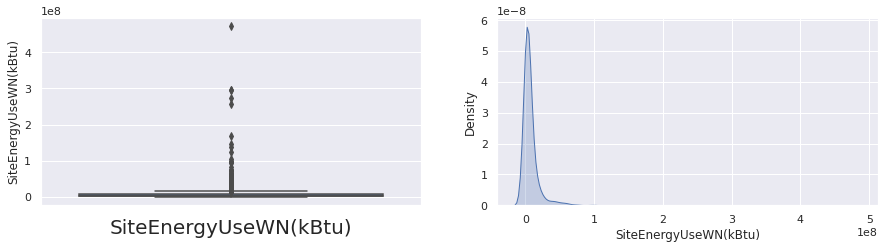

In [150]:
UVA_num_plus(df, ['SiteEnergyUseWN(kBtu)'])

In [ ]:
df['SiteEnergyUseWN(kBtu)'].isna().sum()

In [ ]:
df['SiteEnergyUseWN(kBtu)'].value_counts()

In [ ]:
df.shape

In [151]:
df.loc[df['SiteEnergyUseWN(kBtu)'].isna()]

,DataYear,BuildingType,PrimaryPropertyType,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,SiteEnergyUseWN(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions
563,2016,NonResidential,Large Office,7,DOWNTOWN,47.61051,-122.34439,1979,1.0,7,131143,87160,43983,Office,120248.0,Retail Store,10853.0,No UseType,NaN,NaN,False,Compliant,109.16
578,2016,NonResidential,Small- and Mid-Sized Office,7,DOWNTOWN,47.60380,-122.33293,1924,NaN,4,63150,0,63150,No UseType,NaN,No UseType,NaN,No UseType,NaN,NaN,False,Non-Compliant,NaN
2670,2016,NonResidential,Mixed Use Property,4,NORTHEAST,47.66182,-122.31345,1928,NaN,2,20760,0,20760,No UseType,NaN,No UseType,NaN,No UseType,NaN,NaN,False,Non-Compliant,NaN


In [152]:
df = df.loc[~df['SiteEnergyUseWN(kBtu)'].isna()]

In [153]:
df.shape

(1558, 23)

In [154]:
df.loc[df['SiteEnergyUseWN(kBtu)'] == 0]

,DataYear,BuildingType,PrimaryPropertyType,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,SiteEnergyUseWN(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions
31,2016,SPS-District K-12,K-12 School,7,MAGNOLIA / QUEEN ANNE,47.63290,-122.35172,1989,1.0,2,51582,0,51582,K-12 School,55166.0,No UseType,NaN,No UseType,NaN,0.0,False,Missing Data,10.43
62,2016,SPS-District K-12,K-12 School,1,SOUTHWEST,47.50970,-122.37759,1948,1.0,2,53352,0,53352,K-12 School,65568.0,No UseType,NaN,No UseType,NaN,0.0,False,Missing Data,4.19
81,2016,SPS-District K-12,K-12 School,1,DELRIDGE,47.56360,-122.35800,1999,1.0,3,74468,0,74468,K-12 School,75364.0,No UseType,NaN,No UseType,NaN,0.0,False,Missing Data,11.84
85,2016,SPS-District K-12,K-12 School,2,SOUTHEAST,47.57324,-122.29058,1991,1.0,2,58933,0,58933,K-12 School,60725.0,No UseType,NaN,No UseType,NaN,0.0,False,Missing Data,16.36
95,2016,SPS-District K-12,K-12 School,6,LAKE UNION,47.65464,-122.34912,1991,1.0,3,66588,0,66588,K-12 School,66588.0,No UseType,NaN,No UseType,NaN,0.0,False,Missing Data,14.67
133,2016,SPS-District K-12,K-12 School,6,BALLARD,47.69675,-122.37760,1959,1.0,1,160270,0,160270,K-12 School,160270.0,No UseType,NaN,No UseType,NaN,0.0,False,Missing Data,229.38
139,2016,SPS-District K-12,K-12 School,3,CENTRAL,47.59796,-122.30415,1963,1.0,3,136188,0,136188,K-12 School,136188.0,No UseType,NaN,No UseType,NaN,0.0,False,Missing Data,170.90
220,2016,NonResidential,Large Office,7,DOWNTOWN,47.60370,-122.33447,1958,1.0,17,378525,84600,293925,Office,236827.0,Parking,83311.0,Restaurant,14679.0,0.0,False,Compliant,940.47
247,2016,NonResidential,Large Office,7,DOWNTOWN,47.61695,-122.32965,1988,1.0,20,497513,118744,378769,Office,367623.0,Parking,114510.0,No UseType,NaN,0.0,False,Compliant,197.19
284,2016,NonResidential,Large Office,7,DOWNTOWN,47.60923,-122.33625,1929,1.0,15,151039,0,151039,Office,125473.0,No UseType,NaN,No UseType,NaN,0.0,False,Compliant,238.09


In [155]:
df.loc[df['SiteEnergyUseWN(kBtu)'] == 0].any(1).count()

20

In [156]:
df.loc[df['SiteEnergyUseWN(kBtu)'] > 0].shape

(1538, 23)

In [157]:
df = df.loc[df['SiteEnergyUseWN(kBtu)'] > 0]

In [158]:
df.shape

(1538, 23)

#### NumberOfBuildings

TypeError: lineplot() takes from 0 to 1 positional arguments but 2 were given

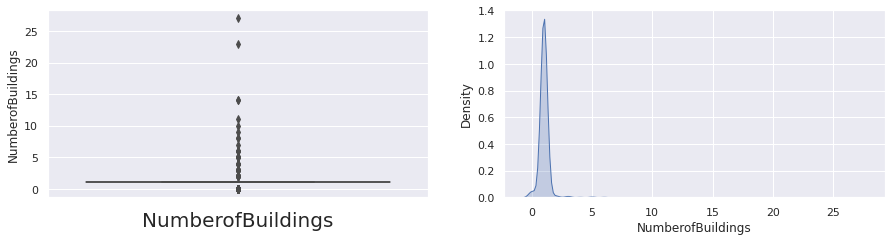

In [159]:
UVA_num_plus(df, ['NumberofBuildings'])

In [ ]:
df['NumberofBuildings'].isna().sum()

In [ ]:
df.loc[df['NumberofBuildings'].isna()]

In [ ]:
df['NumberofBuildings'].fillna(1, inplace=True)

In [160]:
df['NumberofBuildings'].value_counts()

1.0     1440
0.0       49
2.0       14
3.0       11
5.0        6
4.0        4
6.0        4
14.0       2
8.0        2
27.0       1
11.0       1
9.0        1
7.0        1
23.0       1
10.0       1
Name: NumberofBuildings, dtype: int64

In [161]:
nb_build_outl = df.loc[df['NumberofBuildings'] >= 5]

In [162]:
nb_build_outl.all(1).count()

20

In [163]:
nb_build_outl

,DataYear,BuildingType,PrimaryPropertyType,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,SiteEnergyUseWN(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions
105,2016,Campus,University,1,DELRIDGE,47.547000,-122.353070,1970,27.0,2,441071,0,441071,College/University,483000.0,No UseType,NaN,No UseType,NaN,4.115173e+07,False,Compliant,866.23
124,2016,NonResidential,Hospital,4,NORTHEAST,47.662310,-122.281460,1953,6.0,10,879000,0,879000,Hospital (General Medical & Surgical),879000.0,No UseType,NaN,No UseType,NaN,2.577642e+08,False,Compliant,8145.52
128,2016,Campus,University,5,NORTHWEST,47.699360,-122.334010,1970,11.0,2,694072,111625,582447,College/University,667335.0,No UseType,NaN,No UseType,NaN,3.741080e+07,False,Compliant,362.82
162,2016,Campus,Large Office,1,GREATER DUWAMISH,47.524290,-122.312340,1980,14.0,2,334368,31874,302494,Office,240984.0,Laboratory,72963.0,Other - Utility,16766.0,5.413607e+07,False,Compliant,748.55
167,2016,NonResidential,Hospital,3,CENTRAL,47.607050,-122.309660,1990,6.0,5,597519,0,597519,Hospital (General Medical & Surgical),601615.0,Parking,48607.0,No UseType,NaN,1.472991e+08,False,Compliant,4906.33
170,2016,NonResidential,Hospital,3,EAST,47.603990,-122.323770,2000,9.0,8,1158691,0,1158691,Hospital (General Medical & Surgical),1350182.0,Parking,387651.0,No UseType,NaN,2.966717e+08,False,Compliant,10734.57
364,2016,NonResidential,Other,5,NORTHWEST,47.725460,-122.346590,1964,6.0,1,111900,0,111900,Strip Mall,124231.0,Parking,0.0,No UseType,NaN,1.007999e+07,False,Compliant,226.43
618,2016,NonResidential,Hospital,3,EAST,47.608951,-122.322402,1994,7.0,14,1765970,0,1765970,Hospital (General Medical & Surgical),1639334.0,Parking,441551.0,No UseType,NaN,2.959299e+08,False,Compliant,12307.16
954,2016,Campus,K-12 School,4,NORTHEAST,47.687000,-122.300130,1989,5.0,3,21500,0,21500,K-12 School,96154.0,No UseType,NaN,No UseType,NaN,7.109712e+06,False,Compliant,202.65
1670,2016,NonResidential,Other,5,NORTHWEST,47.709690,-122.345570,1970,5.0,1,23166,0,23166,Other,23166.0,No UseType,NaN,No UseType,NaN,3.648466e+06,False,Compliant,184.60


In [164]:
nb_build_outl[['DataYear', 'BuildingType', 'PrimaryPropertyType',
       'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'LargestPropertyUseType', 'LargestPropertyUseTypeGFA','SiteEnergyUseWN(kBtu)',
       'ComplianceStatus', 'TotalGHGEmissions']].sort_values(by=['NumberofBuildings'], ascending=False)

,DataYear,BuildingType,PrimaryPropertyType,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,LargestPropertyUseType,LargestPropertyUseTypeGFA,SiteEnergyUseWN(kBtu),ComplianceStatus,TotalGHGEmissions
105,2016,Campus,University,1970,27.0,2,441071,College/University,483000.0,4.115173e+07,Compliant,866.23
1862,2016,Campus,Other,1955,23.0,1,260241,Other,260241.0,3.603458e+07,Compliant,565.55
162,2016,Campus,Large Office,1980,14.0,2,334368,Office,240984.0,5.413607e+07,Compliant,748.55
2325,2016,Campus,University,1945,14.0,2,537000,College/University,533826.0,9.677546e+07,Compliant,3768.66
128,2016,Campus,University,1970,11.0,2,694072,College/University,667335.0,3.741080e+07,Compliant,362.82
1993,2016,Campus,Other,1991,10.0,0,230971,Other,230970.0,2.223084e+07,Compliant,405.05
170,2016,NonResidential,Hospital,2000,9.0,8,1158691,Hospital (General Medical & Surgical),1350182.0,2.966717e+08,Compliant,10734.57
1672,2016,NonResidential,Hospital,1966,8.0,1,415632,Hospital (General Medical & Surgical),483520.0,1.003283e+08,Compliant,3278.11
3168,2016,Nonresidential COS,Other,1929,8.0,0,502030,Other - Recreation,564258.0,2.067295e+07,Compliant,549.11
618,2016,NonResidential,Hospital,1994,7.0,14,1765970,Hospital (General Medical & Surgical),1639334.0,2.959299e+08,Compliant,12307.16


In [165]:
# replace NumberofBuildings value from 0 to 1
df['NumberofBuildings'].loc[df['NumberofBuildings'] == 0] = 1

In [166]:
df['NumberofBuildings'].value_counts()

1.0     1489
2.0       14
3.0       11
5.0        6
4.0        4
6.0        4
14.0       2
8.0        2
27.0       1
11.0       1
9.0        1
7.0        1
23.0       1
10.0       1
Name: NumberofBuildings, dtype: int64

#### LargestPropertyUseTypeGFA 

In [167]:
df['LargestPropertyUseTypeGFA'].isna().sum()

4

TypeError: lineplot() takes from 0 to 1 positional arguments but 2 were given

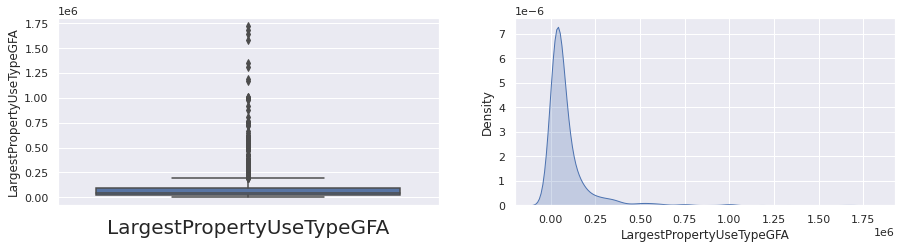

In [168]:
UVA_num_plus(df, ['LargestPropertyUseTypeGFA'])

In [ ]:
df['LargestPropertyUseTypeGFA'].value_counts()

In [ ]:
df.loc[df['LargestPropertyUseTypeGFA'].isna()]

#### SecondLargestPropertyUseTypeGFA

In [169]:
df['SecondLargestPropertyUseTypeGFA'].isna().sum()

751

In [170]:
df['SecondLargestPropertyUseTypeGFA'].nunique()

650

In [171]:
df['SecondLargestPropertyUseTypeGFA'].value_counts()

0.000000         73
15000.000000      8
5000.000000       7
8000.000000       6
7200.000000       5
6000.000000       5
20000.000000      4
7500.000000       4
18000.000000      4
7000.000000       3
10000.000000      3
4000.000000       3
1500.000000       3
2600.000000       2
13000.000000      2
30000.000000      2
26640.000000      2
11000.000000      2
4800.000000       2
12000.000000      2
4500.000000       2
3500.000000       2
10500.000000      2
100000.000000     2
1000.000000       2
9600.000000       2
17200.000000      2
8200.000000       2
40000.000000      2
5120.000000       2
2500.000000       2
14400.000000      2
3000.000000       2
8800.000000       2
4968.000000       2
11550.000000      1
22198.000000      1
23501.000000      1
6728.000000       1
8399.000000       1
2648.000000       1
2900.000000       1
5300.000000       1
5091.000000       1
4101.000000       1
2294.000000       1
4860.000000       1
13941.000000      1
2266.000000       1
49758.000000      1


In [172]:
# count how many na occurences
df.loc[df['SecondLargestPropertyUseTypeGFA'].isna()].any(1).sum()

751

In [173]:
# check correspondent usetype
df['SecondLargestPropertyUseType'].loc[df['SecondLargestPropertyUseTypeGFA'].isna()].unique()

array(['No UseType'], dtype=object)

In [174]:
df.loc[df['SecondLargestPropertyUseTypeGFA'] == 0]

,DataYear,BuildingType,PrimaryPropertyType,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,SiteEnergyUseWN(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions
80,2016,NonResidential,Hotel,4,NORTHEAST,47.65772,-122.31756,1962,2.0,4,50017,0,50017,Hotel,50017.0,Swimming Pool,0.0,No UseType,NaN,5.528580e+06,False,Compliant,191.20
90,2016,NonResidential,Other,4,NORTHEAST,47.67559,-122.31769,1929,1.0,2,206934,0,206934,Other,119146.0,Parking,0.0,No UseType,NaN,4.384626e+06,False,Compliant,133.58
91,2016,NonResidential,Hotel,5,NORTHWEST,47.73141,-122.34580,2001,1.0,4,51390,0,51390,Hotel,51390.0,Parking,0.0,No UseType,NaN,3.616214e+06,False,Compliant,127.29
116,2016,SPS-District K-12,K-12 School,5,NORTH,47.70763,-122.29453,2011,1.0,2,236758,0,236758,K-12 School,238550.0,Parking,0.0,No UseType,NaN,9.287467e+06,False,Compliant,222.78
155,2016,NonResidential,Other,2,GREATER DUWAMISH,47.59544,-122.33159,1999,1.0,6,1585960,327680,1258280,Other - Entertainment/Public Assembly,1585960.0,Parking,0.0,No UseType,NaN,6.216030e+07,False,Compliant,892.63
262,2016,NonResidential,Hotel,7,DOWNTOWN,47.60804,-122.33391,1923,1.0,12,542305,0,542305,Hotel,542305.0,Swimming Pool,0.0,No UseType,NaN,5.705124e+07,False,Compliant,2573.75
319,2016,NonResidential,Large Office,7,MAGNOLIA / QUEEN ANNE,47.62929,-122.34194,1996,2.0,5,213283,115228,98055,Office,105563.0,Parking,0.0,No UseType,NaN,5.661690e+06,False,Compliant,39.47
321,2016,NonResidential,Small- and Mid-Sized Office,5,NORTH,47.70105,-122.32659,1974,1.0,5,74880,0,74880,Office,71751.0,Parking,0.0,No UseType,NaN,5.531460e+06,False,Compliant,35.80
322,2016,NonResidential,Small- and Mid-Sized Office,5,NORTH,47.69999,-122.32663,1979,1.0,6,88774,0,88774,Office,85339.0,Parking,0.0,No UseType,NaN,6.353294e+06,False,Compliant,42.03
324,2016,NonResidential,Small- and Mid-Sized Office,5,NORTH,47.70063,-122.32487,1979,1.0,4,53730,0,53730,Office,53730.0,Parking,0.0,No UseType,NaN,4.742869e+06,False,Compliant,33.06


In [175]:
df['SecondLargestPropertyUseTypeGFA'].value_counts()

0.000000         73
15000.000000      8
5000.000000       7
8000.000000       6
7200.000000       5
6000.000000       5
20000.000000      4
7500.000000       4
18000.000000      4
7000.000000       3
10000.000000      3
4000.000000       3
1500.000000       3
2600.000000       2
13000.000000      2
30000.000000      2
26640.000000      2
11000.000000      2
4800.000000       2
12000.000000      2
4500.000000       2
3500.000000       2
10500.000000      2
100000.000000     2
1000.000000       2
9600.000000       2
17200.000000      2
8200.000000       2
40000.000000      2
5120.000000       2
2500.000000       2
14400.000000      2
3000.000000       2
8800.000000       2
4968.000000       2
11550.000000      1
22198.000000      1
23501.000000      1
6728.000000       1
8399.000000       1
2648.000000       1
2900.000000       1
5300.000000       1
5091.000000       1
4101.000000       1
2294.000000       1
4860.000000       1
13941.000000      1
2266.000000       1
49758.000000      1


#### ThirdLargestPropertyUseTypeGFA

In [176]:
# count na occurences
df['ThirdLargestPropertyUseTypeGFA'].isna().sum()

1228

In [177]:
df['ThirdLargestPropertyUseTypeGFA'].nunique()

263

In [178]:
# check correspondent usetype
df['ThirdLargestPropertyUseType'].loc[df['ThirdLargestPropertyUseTypeGFA'].isna()].unique()

array(['No UseType'], dtype=object)

In [179]:
df['ThirdLargestPropertyUseTypeGFA'].value_counts()

0.000000         24
5000.000000       6
6000.000000       5
1000.000000       4
1250.000000       3
4000.000000       3
9000.000000       2
3000.000000       2
7500.000000       2
2500.000000       2
2000.000000       2
4500.000000       2
10000.000000      2
6200.000000       2
1500.000000       1
5436.000000       1
4579.000000       1
2788.000000       1
436.000000        1
1440.000000       1
3304.000000       1
2575.000000       1
3609.000000       1
11846.000000      1
4029.000000       1
5225.000000       1
2095.000000       1
8324.000000       1
8199.000000       1
1840.000000       1
3560.000000       1
13945.000000      1
5581.000000       1
2635.000000       1
840.000000        1
5775.000000       1
3200.000000       1
6344.000000       1
4622.000000       1
4438.000000       1
5471.000000       1
2408.000000       1
4270.000000       1
5616.000000       1
15757.000000      1
5636.000000       1
35760.000000      1
6540.000000       1
17000.000000      1
4006.000000       1


In [180]:
df.loc[df['ThirdLargestPropertyUseTypeGFA'] == 0]

,DataYear,BuildingType,PrimaryPropertyType,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,SiteEnergyUseWN(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions
4,2016,NonResidential,Hotel,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,1.465650e+07,False,Compliant,505.01
16,2016,NonResidential,Other,7,DOWNTOWN,47.60546,-122.33279,1930,1.0,6,103911,0,103911,Fitness Center/Health Club/Gym,90000.0,Office,40000.0,Swimming Pool,0.0,1.019212e+07,False,Compliant,433.86
49,2016,NonResidential,Hotel,7,DOWNTOWN,47.61087,-122.33339,1982,1.0,34,994212,146694,847518,Hotel,994212.0,Parking,117668.0,Swimming Pool,0.0,8.231807e+07,False,Compliant,2451.58
144,2016,NonResidential,Hotel,3,LAKE UNION,47.62972,-122.32906,1998,1.0,5,123920,30000,93920,Hotel,123920.0,Parking,30000.0,Swimming Pool,0.0,9.676783e+06,False,Compliant,309.60
331,2016,NonResidential,Retail Store,6,BALLARD,47.66057,-122.36857,1999,1.0,1,164437,0,164437,Retail Store,102653.0,Supermarket/Grocery Store,74102.0,Parking,0.0,1.903157e+07,False,Compliant,326.18
356,2016,NonResidential,Supermarket / Grocery Store,5,NORTH,47.72370,-122.29232,1995,1.0,2,308965,187878,121087,Supermarket/Grocery Store,121087.0,Parking,0.0,Parking,0.0,1.484338e+07,False,Compliant,277.98
400,2016,NonResidential,Refrigerated Warehouse,2,GREATER DUWAMISH,47.56637,-122.33273,1953,1.0,1,104099,0,104099,Refrigerated Warehouse,100000.0,Office,4099.0,Parking,0.0,1.742716e+07,False,Compliant,142.36
403,2016,NonResidential,Large Office,7,LAKE UNION,47.62029,-122.33078,2005,1.0,6,336700,124800,211900,Office,217977.0,Parking,4569.0,Retail Store,0.0,9.200102e+06,False,Compliant,54.92
501,2016,NonResidential,Other,1,DELRIDGE,47.56797,-122.36711,2001,1.0,3,68763,11527,57236,Other - Recreation,50000.0,Parking,11527.0,Swimming Pool,0.0,9.596839e+06,False,Compliant,310.19
542,2016,NonResidential,Supermarket / Grocery Store,6,NORTHWEST,47.69197,-122.35877,1970,1.0,1,141890,35545,106345,Supermarket/Grocery Store,168735.0,Parking,0.0,Parking,0.0,1.738456e+07,False,Compliant,293.56


In [181]:
df['SecondLargestPropertyUseType'].loc[df['ThirdLargestPropertyUseTypeGFA'] == 0].unique()

array(['Parking', 'Office', 'Supermarket/Grocery Store', 'Other',
       'Retail Store', 'Fitness Center/Health Club/Gym', 'Medical Office',
       'Non-Refrigerated Warehouse'], dtype=object)

In [182]:
# fill na
df[['LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA']] = df[['LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA']].fillna(0)

## Distribution post-cleaning

                                                         columns  count  \
DataYear                                                DataYear      0   
PropertyGFABuilding(s)                    PropertyGFABuilding(s)      0   
ComplianceStatus                                ComplianceStatus      0   
DefaultData                                          DefaultData      0   
SiteEnergyUseWN(kBtu)                      SiteEnergyUseWN(kBtu)      0   
ThirdLargestPropertyUseTypeGFA    ThirdLargestPropertyUseTypeGFA      0   
ThirdLargestPropertyUseType          ThirdLargestPropertyUseType      0   
SecondLargestPropertyUseTypeGFA  SecondLargestPropertyUseTypeGFA      0   
SecondLargestPropertyUseType        SecondLargestPropertyUseType      0   
LargestPropertyUseTypeGFA              LargestPropertyUseTypeGFA      0   
LargestPropertyUseType                    LargestPropertyUseType      0   
PropertyGFAParking                            PropertyGFAParking      0   
BuildingType             

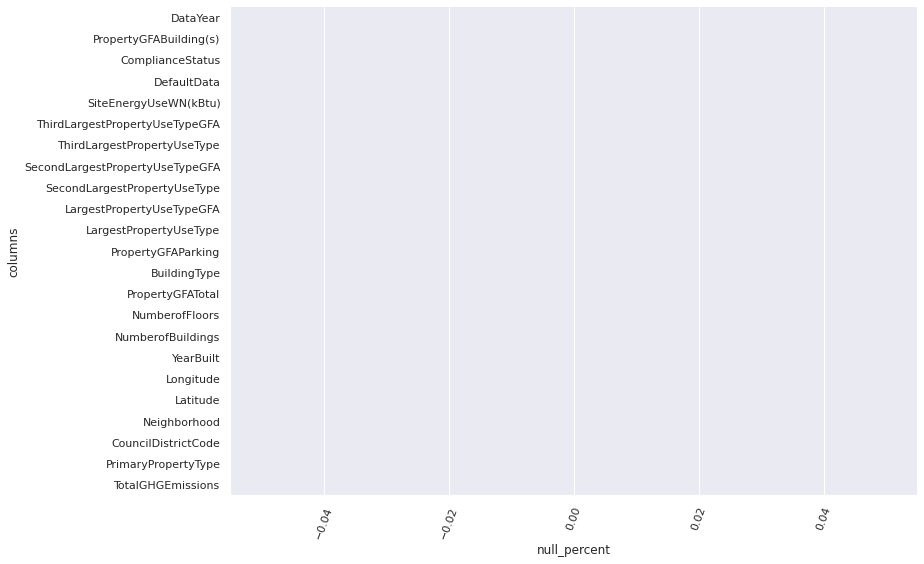

In [183]:
show_nulls(df)

In [184]:
num_cols = df.columns[df.dtypes == 'float64']
num_cols

Index(['Latitude', 'Longitude', 'NumberofBuildings',
       'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseTypeGFA', 'SiteEnergyUseWN(kBtu)',
       'TotalGHGEmissions'],
      dtype='object')

TypeError: lineplot() takes from 0 to 1 positional arguments but 2 were given

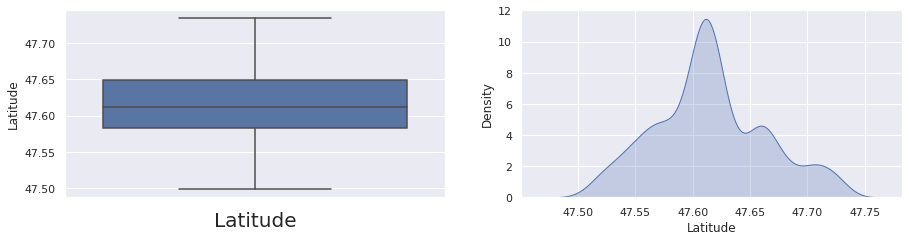

In [185]:
UVA_num_plus(df, num_cols)

### Heatmap / matrice corrélation

In [186]:
### années de construction / influence sur autres params ?
## (heatmap de seaborn)

In [187]:
num_cols = df.columns[df.dtypes == 'float64']
num_cols

Index(['Latitude', 'Longitude', 'NumberofBuildings',
       'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseTypeGFA', 'SiteEnergyUseWN(kBtu)',
       'TotalGHGEmissions'],
      dtype='object')

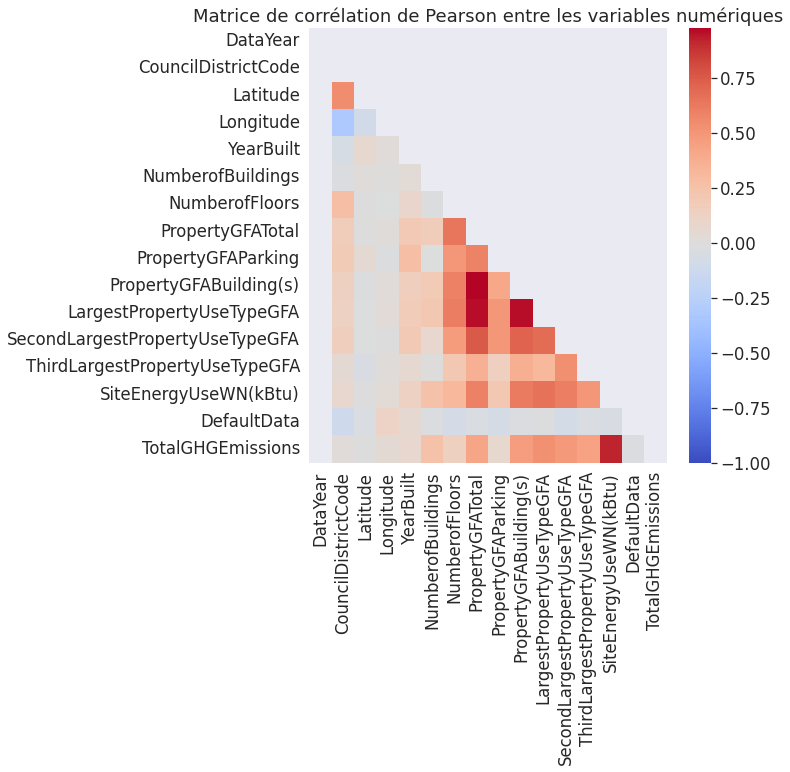

In [188]:
plt.figure(figsize=(8,8))
sns.set(font_scale=1.5)
plt.title('Matrice de corrélation de Pearson entre les variables numériques')


corr = df.corr()
#corr = df[[num_cols]].corr()

#numpy deprecated bool : https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
mask = np.zeros_like(corr, dtype=np.bool_)
mask[np.triu_indices_from(mask)] = True 

ax = sns.heatmap(corr, mask=mask, vmin=-1, cmap='coolwarm')
plt.show()
sns.set(font_scale=1)

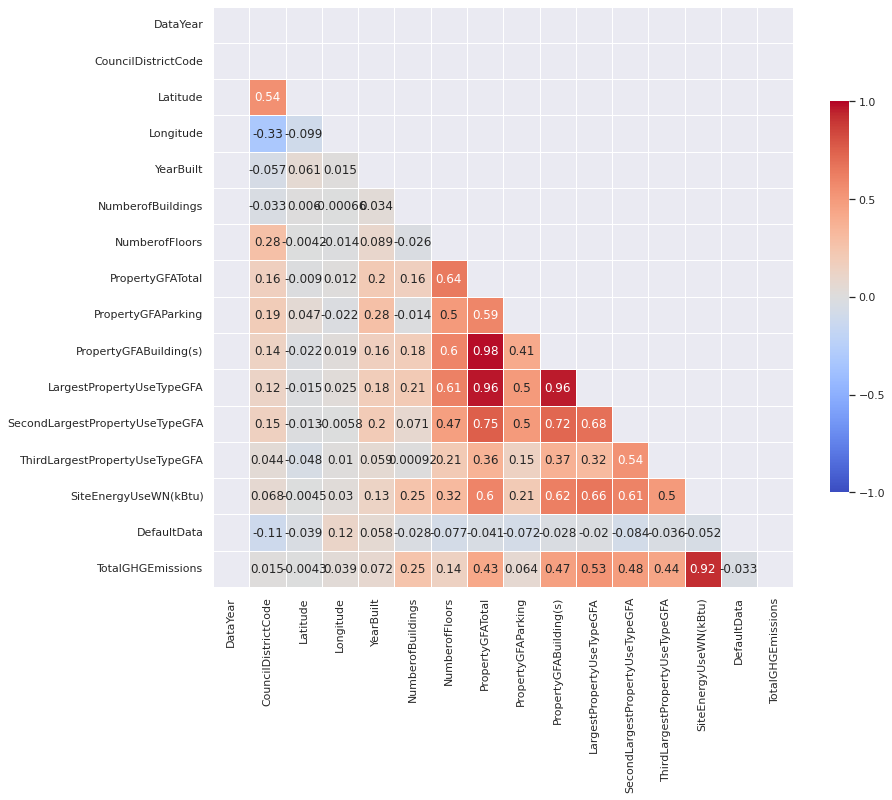

In [189]:
# https://www.kdnuggets.com/2019/07/annotated-heatmaps-correlation-matrix.html

f, ax = plt.subplots(figsize=(13, 18))

corr_matrix = df.corr()

heatmap = sns.heatmap(corr_matrix,
                      mask = mask,
                      square = True,
                      linewidths = .5,
                      cmap = "coolwarm",
                      cbar_kws = {'shrink': .4,
                                "ticks" : [-1, -.5, 0, 0.5, 1]},
                      vmin = -1,
                      vmax = 1,
                      annot = True,
                      annot_kws = {"size": 12})

#add the column names as labels
ax.set_yticklabels(corr_matrix.columns, rotation = 0)
ax.set_xticklabels(corr_matrix.columns)

sns.set_style({'xtick.bottom': True}, {'ytick.left': True})

In [190]:
df.head()

,DataYear,BuildingType,PrimaryPropertyType,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,SiteEnergyUseWN(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions
0,2016,NonResidential,Hotel,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,88434.0,No UseType,0.0,No UseType,0.0,7456910.0,False,Compliant,249.98
1,2016,NonResidential,Hotel,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,8664479.0,False,Compliant,295.86
2,2016,NonResidential,Hotel,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,756493.0,No UseType,0.0,No UseType,0.0,73937112.0,False,Compliant,2089.28
3,2016,NonResidential,Hotel,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,61320.0,No UseType,0.0,No UseType,0.0,6946800.5,False,Compliant,286.43
4,2016,NonResidential,Hotel,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,14656503.0,False,Compliant,505.01


# Explore post-cleaning

## Scatter coordonnées 

In [191]:
countries = gpd.read_file(
               gpd.datasets.get_path("naturalearth_lowres"))
#countries.head()

In [192]:
#countries.plot(color="lightgrey")

In [193]:
#countries.loc[countries.iso_a3 == 'USA'].plot(color="lightgrey")

#### garder uniquement batiments non-résidentiels

In [194]:
gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.Longitude, df.Latitude))

In [195]:
df['BuildingType'].unique()

array(['NonResidential', 'Nonresidential COS', 'SPS-District K-12',
       'Campus', 'Nonresidential WA'], dtype=object)

In [196]:
# get rows with BuildingType with 'Multifamily' prefix
# count code values with 200 prefix
df['BuildingType'].loc[df['BuildingType'].str.startswith('Multifamily')]

Series([], Name: BuildingType, dtype: object)

In [197]:
# remove "MultiFamily" related rows
df = df.loc[~df['BuildingType'].str.startswith('Multifamily')]

In [198]:
df['BuildingType'].unique()

array(['NonResidential', 'Nonresidential COS', 'SPS-District K-12',
       'Campus', 'Nonresidential WA'], dtype=object)

In [199]:
gdf.head()

,DataYear,BuildingType,PrimaryPropertyType,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,SiteEnergyUseWN(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions,geometry
0,2016,NonResidential,Hotel,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,88434.0,No UseType,0.0,No UseType,0.0,7456910.0,False,Compliant,249.98,POINT (-122.33799 47.61220)
1,2016,NonResidential,Hotel,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,8664479.0,False,Compliant,295.86,POINT (-122.33393 47.61317)
2,2016,NonResidential,Hotel,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,756493.0,No UseType,0.0,No UseType,0.0,73937112.0,False,Compliant,2089.28,POINT (-122.33810 47.61393)
3,2016,NonResidential,Hotel,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,61320.0,No UseType,0.0,No UseType,0.0,6946800.5,False,Compliant,286.43,POINT (-122.33664 47.61412)
4,2016,NonResidential,Hotel,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,14656503.0,False,Compliant,505.01,POINT (-122.34047 47.61375)


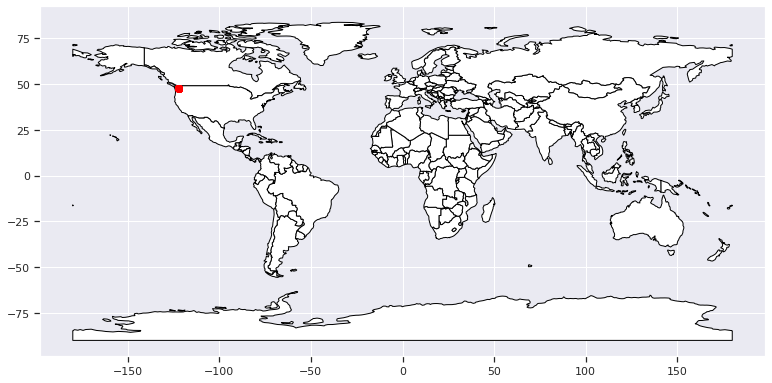

In [200]:
ax = countries.plot(
    color='white', edgecolor='black')

# plot``GeoDataFrame``.
gdf.plot(ax=ax, color='red')

plt.show()

In [201]:
mean_lat = df['Latitude'].describe()['mean']
mean_lat

47.615026263647586

In [202]:
mean_lon = df['Longitude'].describe()['mean']
mean_lon

-122.3331850719766

In [203]:
#place_name = 'Seattle, USA'
#tags = {'building': True}
#area = ox.geometries.geometries_from_place(place_name, tags)
#area.plot()

In [204]:
map = folium.Map(location=[mean_lat, mean_lon], zoom_start=11)

locations = df[['Latitude', 'Longitude']]
locationlist = locations.values.tolist()

for coord in locationlist:
    folium.Marker(
            location=[ coord[0], coord[1] ], 
            fill_color='#43d9de', radius=8).add_to(map)

map.save( 'map_s.html')

map

In [205]:
### avec coordonnées vérifier existence de quartiers / groupes

In [206]:
# folium doc : https://python-visualization.github.io/folium/modules.html
# article : https://towardsdatascience.com/folium-mapping-displaying-markers-on-a-map-6bd56f3e3420

In [207]:
colors_list = ['beige', 'black', 'blue', 'cadetblue', 'darkblue', 'darkgreen', 'darkpurple', 
 'darkred', 'gray', 'green', 'lightblue', 'lightgray', 'lightgreen', 'lightred', 
 'orange', 'pink', 'purple', 'red', 'white']

In [208]:
len(colors_list)

19

In [209]:
df['Neighborhood'].nunique()

13

In [210]:
df['Neighborhood'].nunique()

13

In [211]:
cat_cols = df.columns[df.dtypes == 'object']
cat_cols

Index(['BuildingType', 'PrimaryPropertyType', 'Neighborhood',
       'LargestPropertyUseType', 'SecondLargestPropertyUseType',
       'ThirdLargestPropertyUseType', 'ComplianceStatus'],
      dtype='object')

In [212]:
df[cat_cols].describe()

,BuildingType,PrimaryPropertyType,Neighborhood,LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,ComplianceStatus
count,1538,1538,1538,1538,1538,1538,1538
unique,5,19,13,51,45,37,2
top,NonResidential,Small- and Mid-Sized Office,GREATER DUWAMISH,Office,No UseType,No UseType,Compliant
freq,1351,281,337,471,751,1228,1453


In [213]:
quartiers = df['Neighborhood'].unique()
quartiers

array(['DOWNTOWN', 'SOUTHEAST', 'NORTHEAST', 'EAST', 'NORTH',
       'LAKE UNION', 'GREATER DUWAMISH', 'MAGNOLIA / QUEEN ANNE',
       'BALLARD', 'NORTHWEST', 'CENTRAL', 'DELRIDGE', 'SOUTHWEST'],
      dtype=object)

In [214]:
df['Neighborhood'].value_counts()

GREATER DUWAMISH         337
DOWNTOWN                 328
LAKE UNION               140
MAGNOLIA / QUEEN ANNE    140
EAST                     111
NORTHEAST                103
NORTHWEST                 80
BALLARD                   65
NORTH                     62
CENTRAL                   46
DELRIDGE                  46
SOUTHEAST                 42
SOUTHWEST                 38
Name: Neighborhood, dtype: int64

In [215]:
df['Neighborhood'] = df['Neighborhood'].str.upper()
df['Neighborhood'].loc[df['Neighborhood'] == 'DELRIDGE NEIGHBORHOODS'] = 'DELRIDGE'

In [216]:
df['Neighborhood'].value_counts()

GREATER DUWAMISH         337
DOWNTOWN                 328
LAKE UNION               140
MAGNOLIA / QUEEN ANNE    140
EAST                     111
NORTHEAST                103
NORTHWEST                 80
BALLARD                   65
NORTH                     62
CENTRAL                   46
DELRIDGE                  46
SOUTHEAST                 42
SOUTHWEST                 38
Name: Neighborhood, dtype: int64

In [217]:
## => dict fonction zip

In [218]:
dict_cols = dict(zip(quartiers, colors_list))

dict_cols

{'DOWNTOWN': 'beige',
 'SOUTHEAST': 'black',
 'NORTHEAST': 'blue',
 'EAST': 'cadetblue',
 'NORTH': 'darkblue',
 'LAKE UNION': 'darkgreen',
 'GREATER DUWAMISH': 'darkpurple',
 'MAGNOLIA / QUEEN ANNE': 'darkred',
 'BALLARD': 'gray',
 'NORTHWEST': 'green',
 'CENTRAL': 'lightblue',
 'DELRIDGE': 'lightgray',
 'SOUTHWEST': 'lightgreen'}

In [219]:
dict_cols.values()

dict_values(['beige', 'black', 'blue', 'cadetblue', 'darkblue', 'darkgreen', 'darkpurple', 'darkred', 'gray', 'green', 'lightblue', 'lightgray', 'lightgreen'])

In [220]:
dict_cols["DOWNTOWN"]

'beige'

In [221]:
for i,row in df.iterrows():
    #Setup the content of the popup
    iframe = folium.IFrame(f'Neighborhood: {str(row["Neighborhood"])} \n Type: {str(row["PrimaryPropertyType"])}')
    
    #Initialise the popup using the iframe
    popup = folium.Popup(iframe, min_width=300, max_width=300)
    
    try:
        icon_color = dict_cols[row['Neighborhood']]
    except:
        #Catch nans
        icon_color = 'gray'
    
    #Add each row to the map
    folium.Marker(location=[row['Latitude'],row['Longitude']],
                  popup = popup, 
                  icon=folium.Icon(color=icon_color, icon='')).add_to(map)
    
    

In [222]:
map

# Export to CSV

In [227]:
df.reset_index()

#df.to_csv(path + 'clean_seattle_buildings.csv', index=False)
print('export finished !')

export finished !


In [228]:
pwd

'/home/mijka/code/openclassrooms/projets/projet_4'

In [229]:
ls -lh ./data

total 1,5M
-rw-r--r-- 1 mijka mijka 1,2M  5 févr. 09:37 2016_Building_Energy_Benchmarking.csv
-rw-r--r-- 1 mijka mijka 320K  5 févr. 09:52 clean_seattle_buildings.csv


In [226]:
#df['ENERGYSTARScore'].value_counts()

In [ ]:
#from sklearn import preprocessing
#le = preprocessing.LabelEncoder()

In [ ]:
#df[cat_cols] = le.fit_transform(df[cat_cols].astype(str))

In [ ]:
## 2023-02-05 mentorat :
## 
## /!\ si valeurs nan cible => pas remplacer, supprimer
## 